# Test Base for Visualizations

**Date: 03-30-2026**

## Introduction

- This notebook is a lighter test base for developers to test **visualization** functions using results from lymphnode_analysis workbook in "../paper/example/lymphnode_analysis.ipynb". 
- All data transformation are omitted while the original section number are kept.

### How to use this notebook for testing

- Make a copy of the notebook in your test branch.
- Pull your code into the branch.
- Make sure the kernel is set as the python environment created from environmental.yml
- Check through the notebook and find cells related to your work. You may delete or comment out unrelated sections. Then write your own testing cells.
- Run cells from top to bottom.

### Dataset Overview
We use the final result from the lymphnode_analysis.ipynb, which is stored in "../data/dev_example.pickle"

Below is the overview of the original dataset
- **Source**: This example uses scimap demo dataset (https://scimap.xyz/tutorials/md/demo_data_scimap/), with additional annotations added for phenotyping analysis named as "example_lymphnode_data.csv". The original data is publicly available normal human lymph node tissue microarray data from CyCIF imaging, preprocessed by MCMICRO. No additional ethical approvals are required for this de-identified published dataset. 
- **Size**: 4,825 cells
- **Markers**: 33 protein markers

## Module Imports & Utility Functions

In [1]:
# Import functions from the updated SPAC package
from spac.data_utils import load_csv_files, select_values, combine_dfs, ingest_cells 
from spac.transformations import arcsinh_transformation, z_score_normalization, run_umap, phenograph_clustering
from spac.visualization import boxplot, histogram, hierarchical_heatmap, dimensionality_reduction_plot, spatial_plot, sankey_plot, visualize_nearest_neighbor, plot_ripley_l
from spac.spatial_analysis import spatial_interaction, calculate_nearest_neighbor, ripley_l
from spac.phenotyping import assign_manual_phenotypes
from spac.transformations import rename_annotations
from functools import partial

import numpy as np
import pandas as pd
from math import ceil, sqrt
import matplotlib.pyplot as plt
import seaborn as sns 
import copy
import anndata
import scanpy as sc
import plotly.io as pio
from PIL import Image as PILImage
from pprint import pprint
from io import BytesIO
%matplotlib inline

# Reduce verbosity settings
import warnings
warnings.filterwarnings('ignore')

# Configure root logger to suppress INFO
# Set logging to only show warnings and errors
import logging
import sys
logging.getLogger().setLevel(logging.WARNING)

# Configure specific loggers
logging.getLogger('spac').setLevel(logging.WARNING)
logging.getLogger('spac.utils').setLevel(logging.WARNING)  # In case of sub-loggers
logging.getLogger('spac.visualization').setLevel(logging.WARNING)

# Also disable propagation to root logger
logging.getLogger('spac').propagate = False

# For scanpy verbosity
sc.settings.verbosity = 1  # Only show errors
# Set visualization parameters
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Suppress matplotlib debug messages
logging.getLogger('matplotlib').setLevel(logging.WARNING)


## Define Input/Output Paths

In [2]:
# Setup file paths
data_pickle = "../data/dev_example.pickle"

## Utility Functions

In [3]:
def generate_grid_frame(adata, fig_width=12, fig_height=12, dpi=300, n_plots=None):
    """Generate a grid frame for multiple subplots."""
    if n_plots is None:
        n_annotations = len(adata.obs.columns.tolist())
    else:
        n_annotations = n_plots
    
    n_cols = ceil(sqrt(n_annotations))
    n_rows = ceil(n_annotations / n_cols)
    
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(fig_width, fig_height),
        dpi=dpi
    )
    axes = axes.flatten()
    return fig, axes

# This function is from https://github.com/FNLCR-DMAP/SPAC_Shiny/blob/main/utils/data_processing.py
def load_data(file_path):
    """
    Load data from a specified file path. Supports .h5ad and .pickle formats.
    
    Parameters:
        file_path (str): The path to the data file.

    Returns:
        adata: Loaded AnnData object or None if loading fails.
    """
    try:
        with open(file_path, 'rb') as file:
            if file_path.endswith('.h5ad'):
                try:
                    adata = ad.read_h5ad(file)
                    return adata
                except Exception as e:
                    print(f"Error loading .h5ad file: {e}")
                    return None
            elif file_path.endswith('.pickle'):
                try:
                    adata = pd.read_pickle(file)
                    return adata
                except Exception as e:
                    print(f"Error loading .pickle file: {e}")
                    return None
            else:
                print("Unsupported file format. Please provide a .h5ad or .pickle file.")
                return None
    except FileNotFoundError:
        print(
            f"Preloaded data file {file_path} not found.",
            "Proceeding without preloaded data."
        )

## Step 1: Data Loading & Preprocessing

### 1.1 Load Pickle Data and Create AnnData Object

In [4]:
# # Load data without verbose output
import io
import contextlib

file_path = data_pickle

# Suppress all output from load_data
with io.StringIO() as buf, contextlib.redirect_stdout(buf):
    preloaded_data = load_data(file_path)

# Get the anndata object
adata = preloaded_data[0] if isinstance(preloaded_data, list) else preloaded_data

print(f"AnnData object created: {adata}")
print(f"Number of cells: {adata.n_obs}")
print(f"Number of features: {adata.n_vars}")

AnnData object created: AnnData object with n_obs × n_vars = 4825 × 33
    obs: 'broad_cell_type', 'detailed_cell_type', 'manual_phenotype', 'phenograph_k60_r1', 'renamed_clusters', 'CD3Dspatial_plot', 'CD20spatial_plot'
    uns: 'phenograph_features', 'phenograph_k60_r1_colors', 'renamed_clusters_colors', '_spac_palettes', 'spatial_neighbors', 'renamed_clusters_plot_nhood_enrichment', 'ripley_l_with_edge', 'ripley_l_without_edge', 'ripley_l'
    obsm: 'spatial', 'X_umap', 'spatial_distance'
    layers: 'arcsinh_percentile', 'arcsinh_z_scores'
    obsp: 'spatial_connectivities', 'spatial_distances'
Number of cells: 4825
Number of features: 33


## Step 2: Quality Control and Data Visualization

### 2.1 Marker Expression Distribution

First, let's examine the distribution of all markers to identify potential quality issues.

Calculating Box Plot...
Key QC observations:
- MHCI: High expression in nucleated cells (expected)
- CD45: High expression in immune cells (expected)
- CD20/CD21: High expression in B cells (expected)
- CD56: Unexpectedly high expression - may indicate background noise
  (NK cells are typically rare in normal lymph nodes)


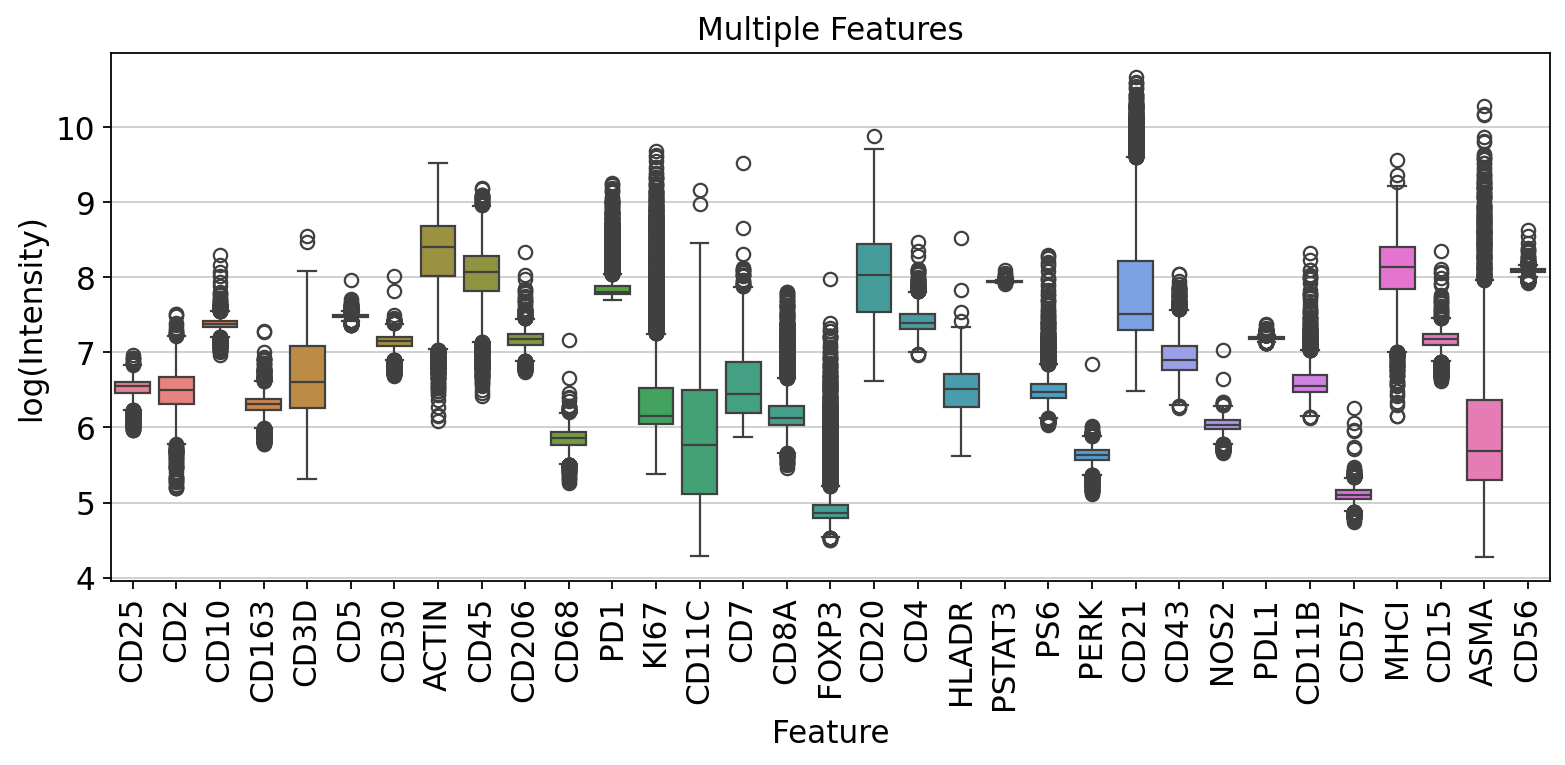

In [5]:
# Create boxplot for all features
summary_stats_table = boxplot(
    adata=adata,
    annotation=None,
    second_annotation=None,
    features=adata.var_names.tolist(),
    layer=None,
    log_scale=True,
    showfliers=True
)

print("Key QC observations:")
print("- MHCI: High expression in nucleated cells (expected)")
print("- CD45: High expression in immune cells (expected)")
print("- CD20/CD21: High expression in B cells (expected)")
print("- CD56: Unexpectedly high expression - may indicate background noise")
print("  (NK cells are typically rare in normal lymph nodes)")

### 2.2 Feature-Specific Histograms

Let's examine CD21 expression across different cell types.

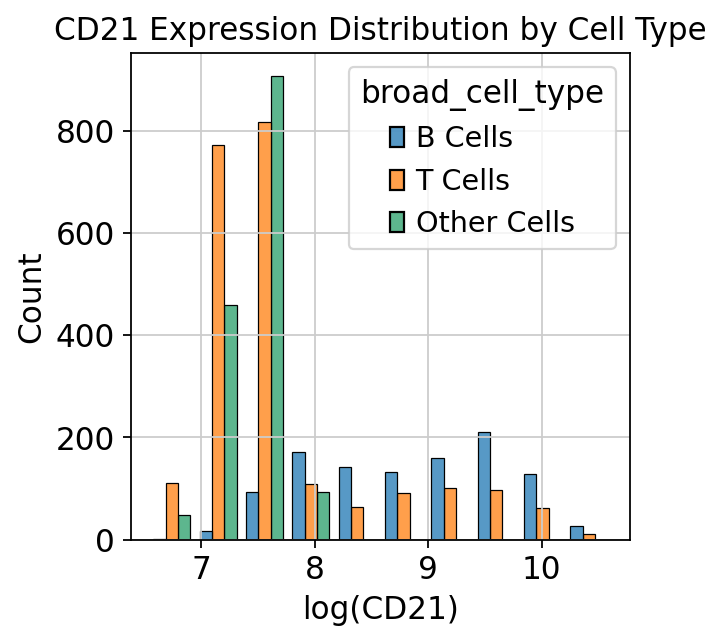

In [6]:
# Create histogram for CD21 expression by cell type
fig = histogram(
    adata, 
    feature="CD21",
    group_by="broad_cell_type",
    layer=None,
    together=True,
    x_log_scale=True,
    y_log_scale=False,
    multiple="dodge",
    shrink=0.8,
    bins="auto",
    alpha=0.75,
    stat="count"
)

plt.title("CD21 Expression Distribution by Cell Type")
plt.show()

## Step 3: Data Transformation

See lymphnode_analysis.ipynb for more details

In [7]:
norm_output_layer = 'arcsinh_percentile'
norm_zscore_input_layer = 'arcsinh_percentile'
norm_zscore_output_layer = 'arcsinh_z_scores'

## Step 4: Unsupervised Clustering

### 4.1 PhenoGraph Clustering

See lymphnode_analysis.ipynb for more details

In [8]:
# Run PhenoGraph clustering
resolution = 1
K_NN_Value = 60
annotation_name = f'phenograph_k{K_NN_Value}_r{resolution}'

# phenograph_clustering(
#     adata,
#     layer=norm_zscore_output_layer,
#     features=adata.var.index.to_list(),
#     k=K_NN_Value,
#     seed=42,
#     output_annotation=annotation_name,
#     resolution_parameter=resolution
# )

num_clusters = adata.obs[annotation_name].nunique()
print(f"PhenoGraph identified {num_clusters} clusters")

# Display cluster sizes
cluster_counts = adata.obs[annotation_name].value_counts().sort_index()
print("\nCells per cluster:")
print(cluster_counts)

PhenoGraph identified 10 clusters

Cells per cluster:
0    971
1    801
2    652
3    650
4    417
5    332
6    326
7    284
8    266
9    126
Name: phenograph_k60_r1, dtype: int64



Generating heatmap to analyze cluster marker expression...


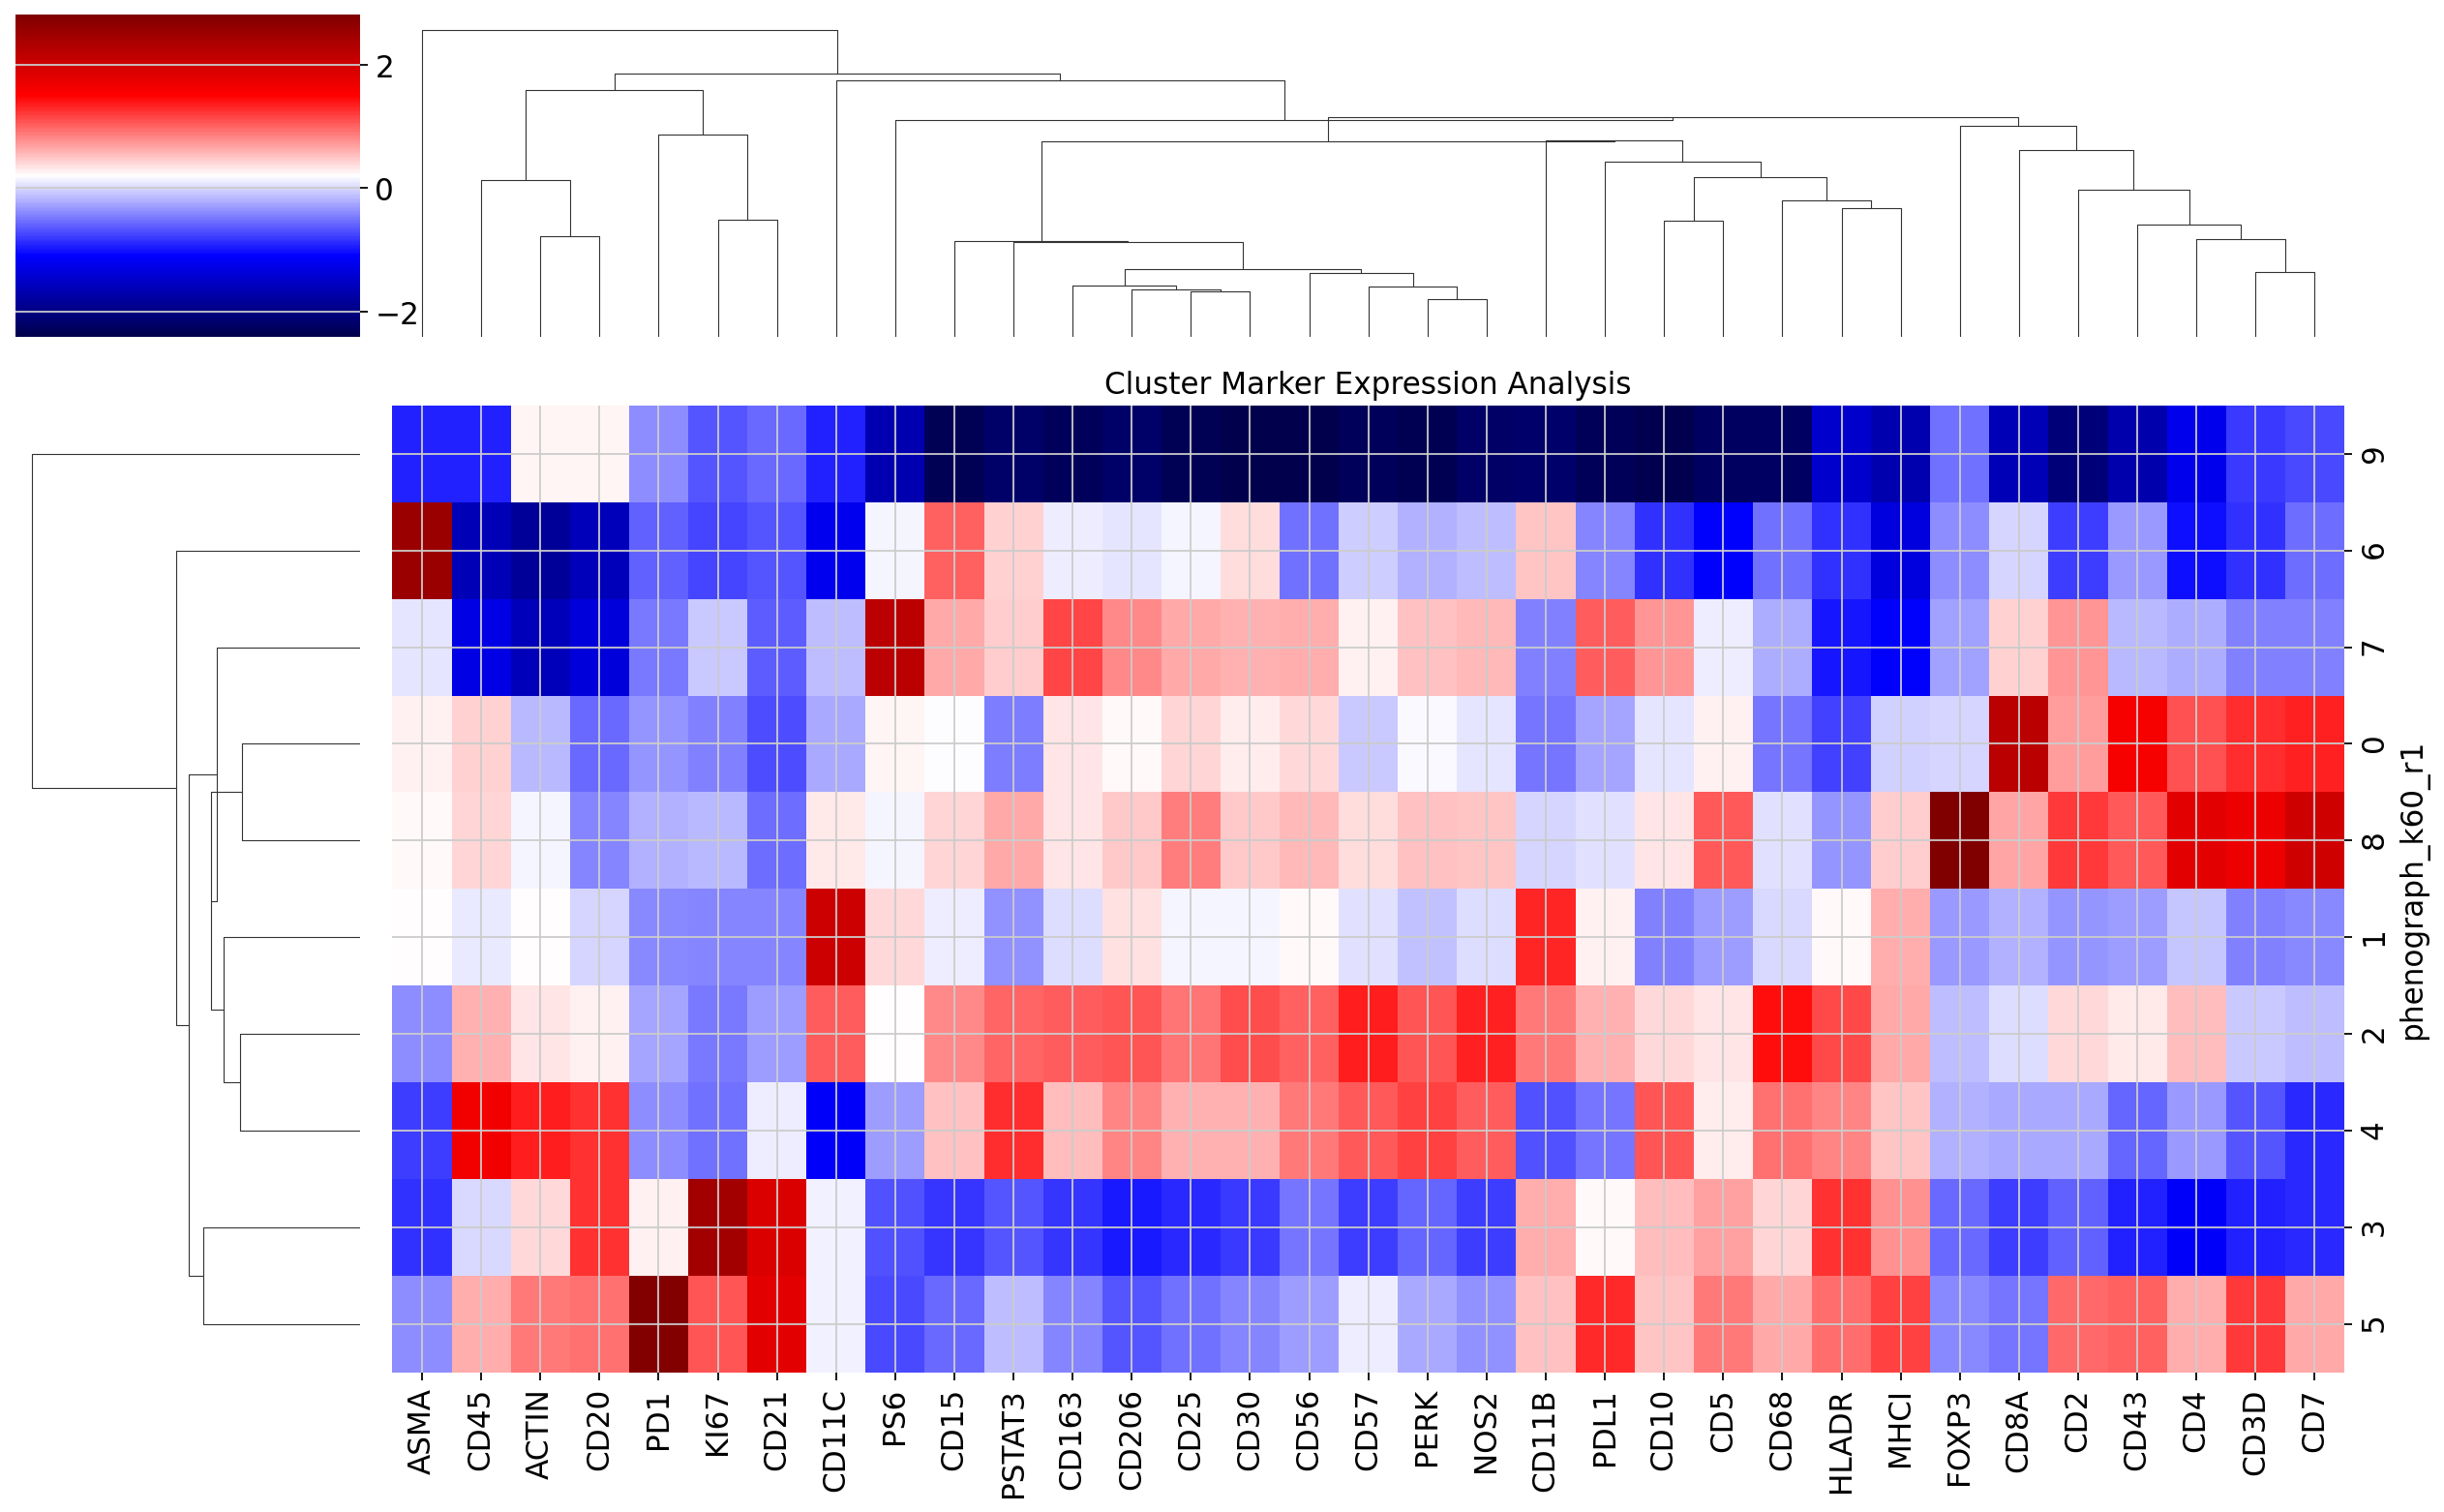

In [9]:
# Create hierarchical heatmap to examine cluster marker expression
print("\nGenerating heatmap to analyze cluster marker expression...")

# Suppress verbose output from heatmap function
with io.StringIO() as buf, contextlib.redirect_stdout(buf):
    _, clustergrid, _ = hierarchical_heatmap(
        adata,
        annotation=annotation_name,
        features=None,  # Use all features
        layer=norm_zscore_output_layer,
        cluster_feature=True,
        cluster_annotations=True,
        standard_scale=None,
        z_score='feature',  # Show relative expression
        swap_axes=False,
        rotate_label=False,
        figsize=(16, 10),
        dendrogram_ratio=(0.15, 0.25),
        cmap='seismic'
    )

clustergrid.ax_heatmap.set_title('Cluster Marker Expression Analysis', fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 Cluster Annotation

See lymphnode_analysis.ipynb for more details

In [10]:
# Define cluster-to-cell type mapping based on marker expression
original_column = f"phenograph_k{K_NN_Value}_r{resolution}"
renamed_column = "renamed_clusters"

## Step 5: Dimensionality Reduction

### 5.1 UMAP Analysis

See lymphnode_analysis.ipynb for more details

### 5.2 Visualize Clusters on UMAP

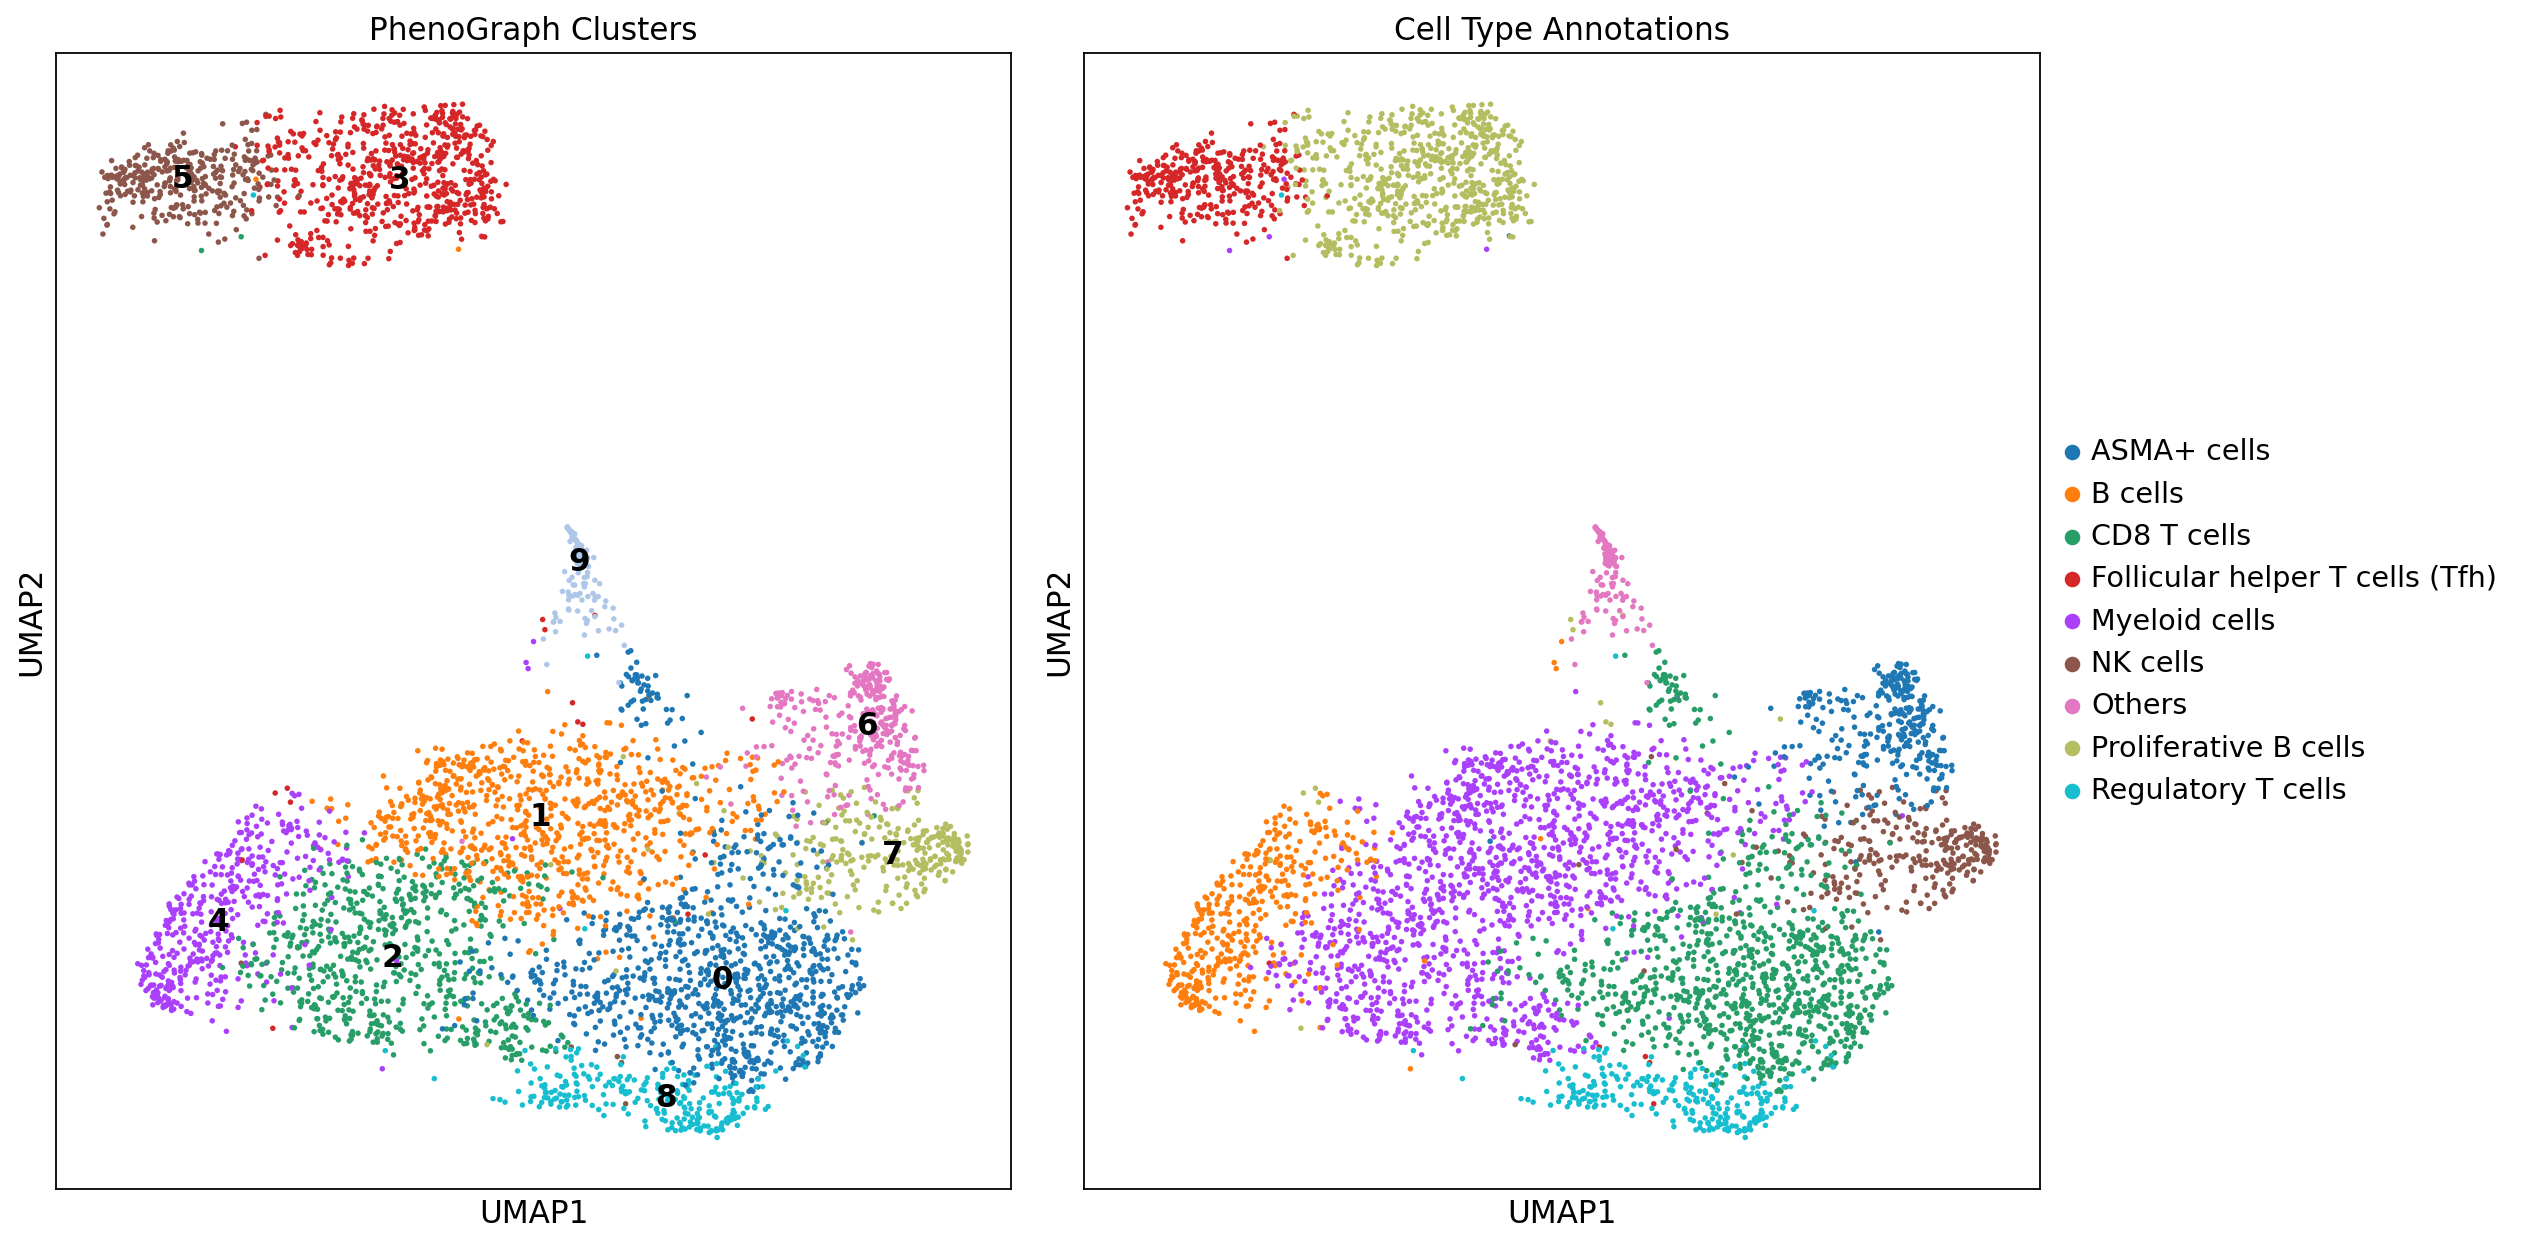

In [11]:
# Create UMAP plots for clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot original clusters
sc.pl.umap(adata, color=original_column, ax=axes[0], show=False, 
           title='PhenoGraph Clusters', legend_loc='on data')

# Plot renamed cell types
sc.pl.umap(adata, color=renamed_column, ax=axes[1], show=False,
           title='Cell Type Annotations', legend_loc='right margin')

plt.tight_layout()
plt.show()

### 5.3 Marker Expression on UMAP

Examine the CD3D/CD20 co-expression boundary that may indicate technical artifacts or biological interactions.

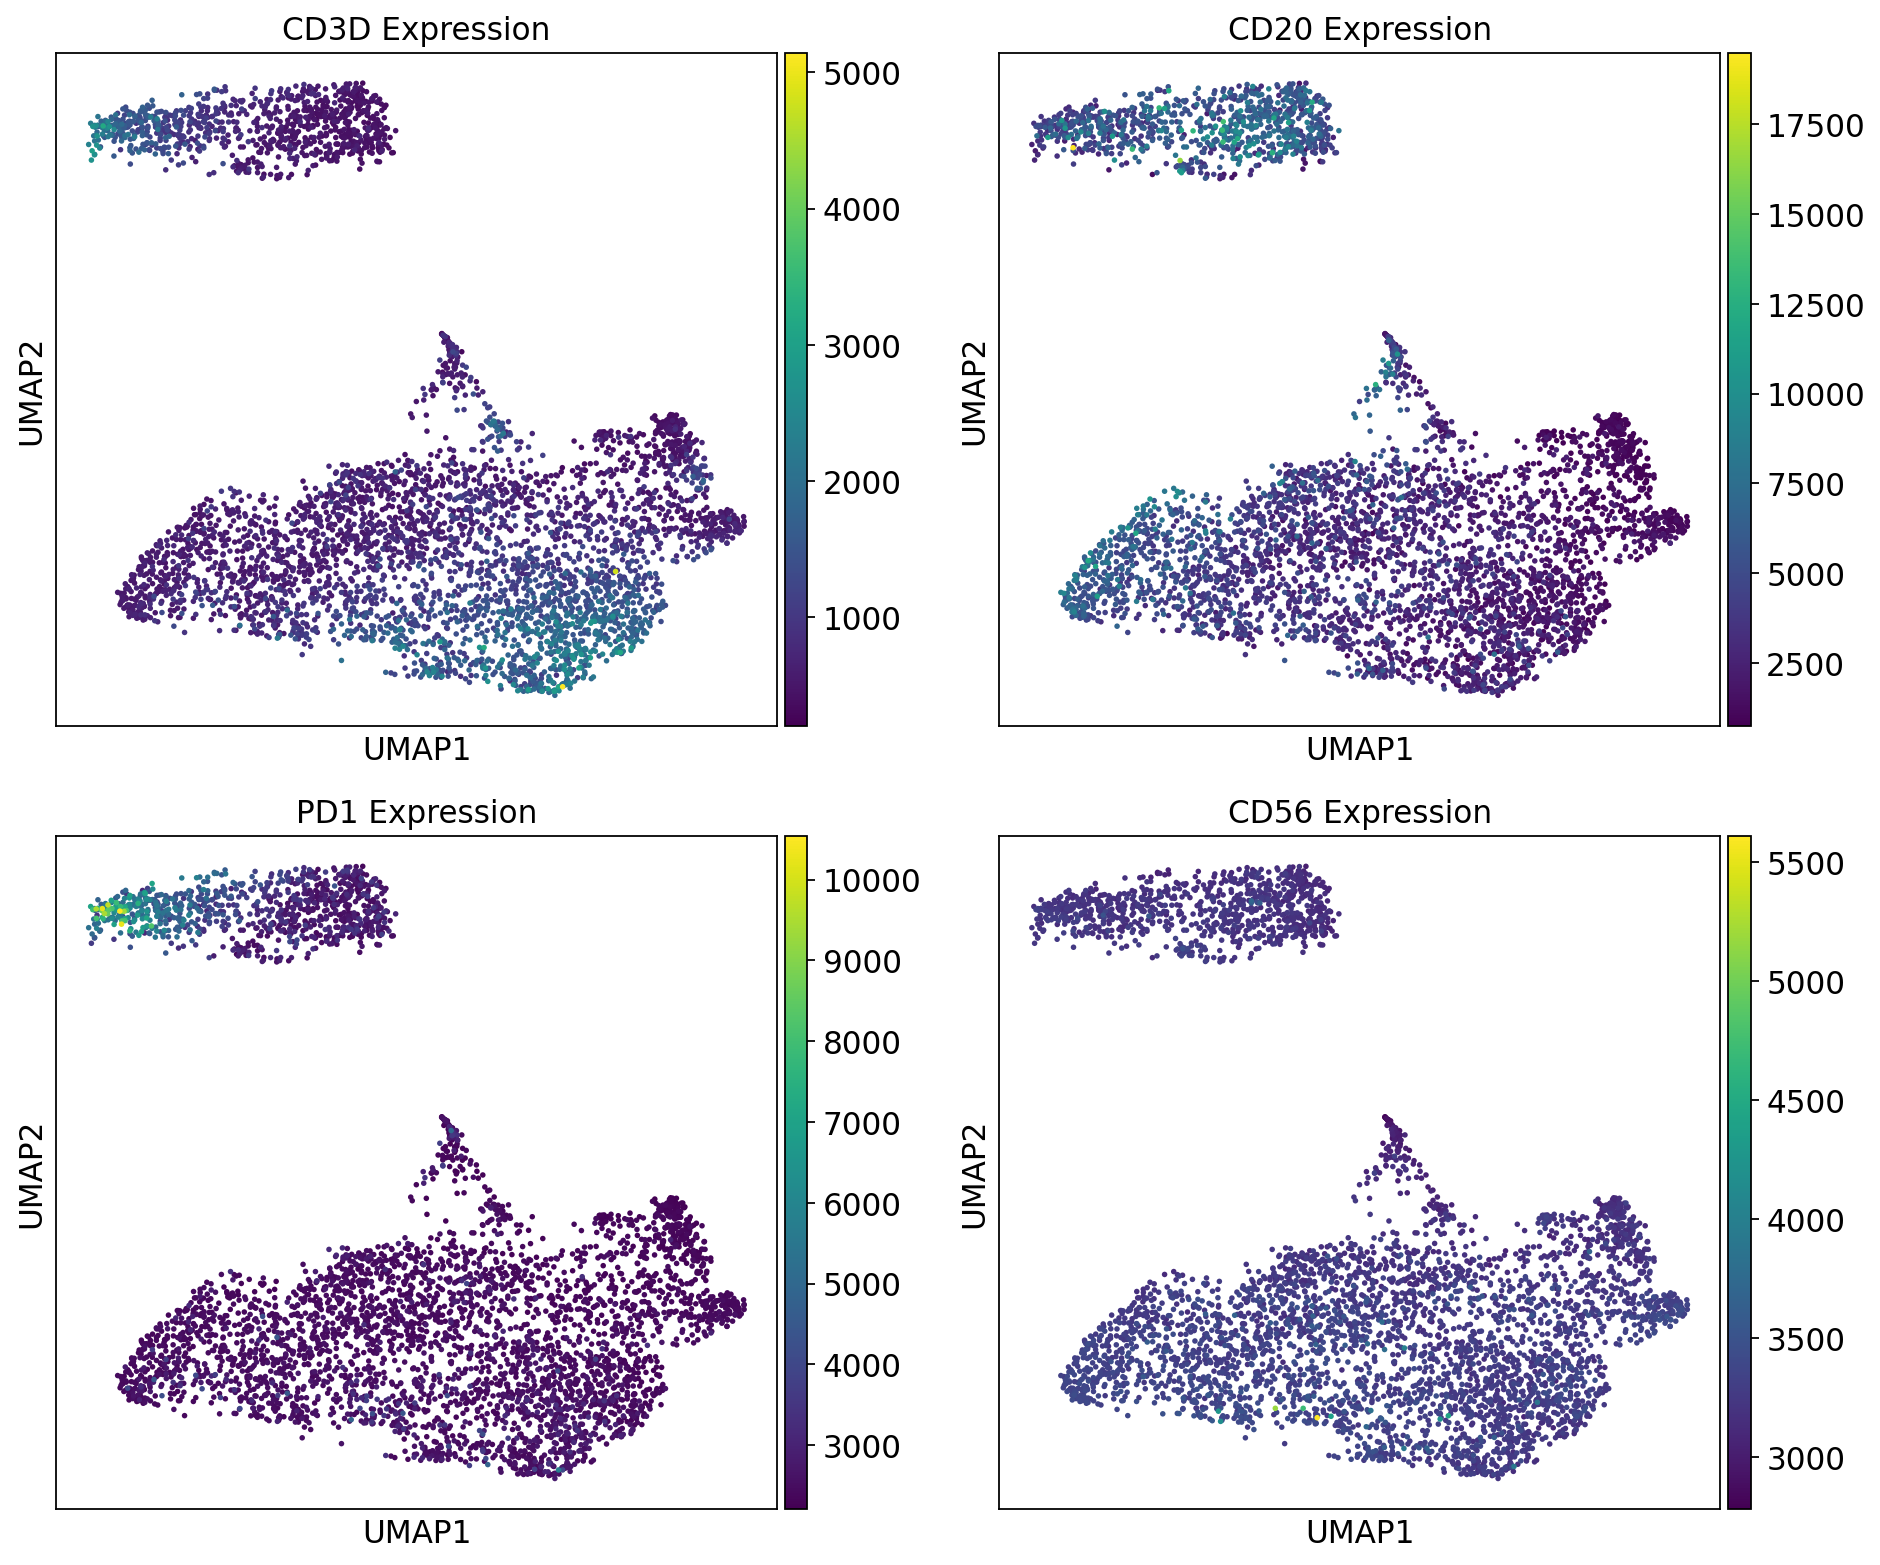

⚠️ Note on CD3D/CD20 boundary:
- Blurred boundaries between CD3D+ and CD20+ cells observed
- May indicate segmentation issues or genuine cell-cell interactions
- Requires validation with original images


In [12]:
# Plot key markers on UMAP
markers_to_plot = ['CD3D', 'CD20', 'PD1', 'CD56']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, marker in enumerate(markers_to_plot):
    sc.pl.umap(adata, color=marker, ax=axes[i], show=False, 
               color_map='viridis', title=f'{marker} Expression')

plt.tight_layout()
plt.show()

print("⚠️ Note on CD3D/CD20 boundary:")
print("- Blurred boundaries between CD3D+ and CD20+ cells observed")
print("- May indicate segmentation issues or genuine cell-cell interactions")
print("- Requires validation with original images")

## Step 6: Hierarchical Clustering Analysis

### 6.1 Heatmap of Marker Expression by Cell Type

Generates a hierarchical clustering heatmap with dendrograms, where features are assumed to be columns and annotations are rows, grouping cells by annotation and calculating average expression intensities for each feature.

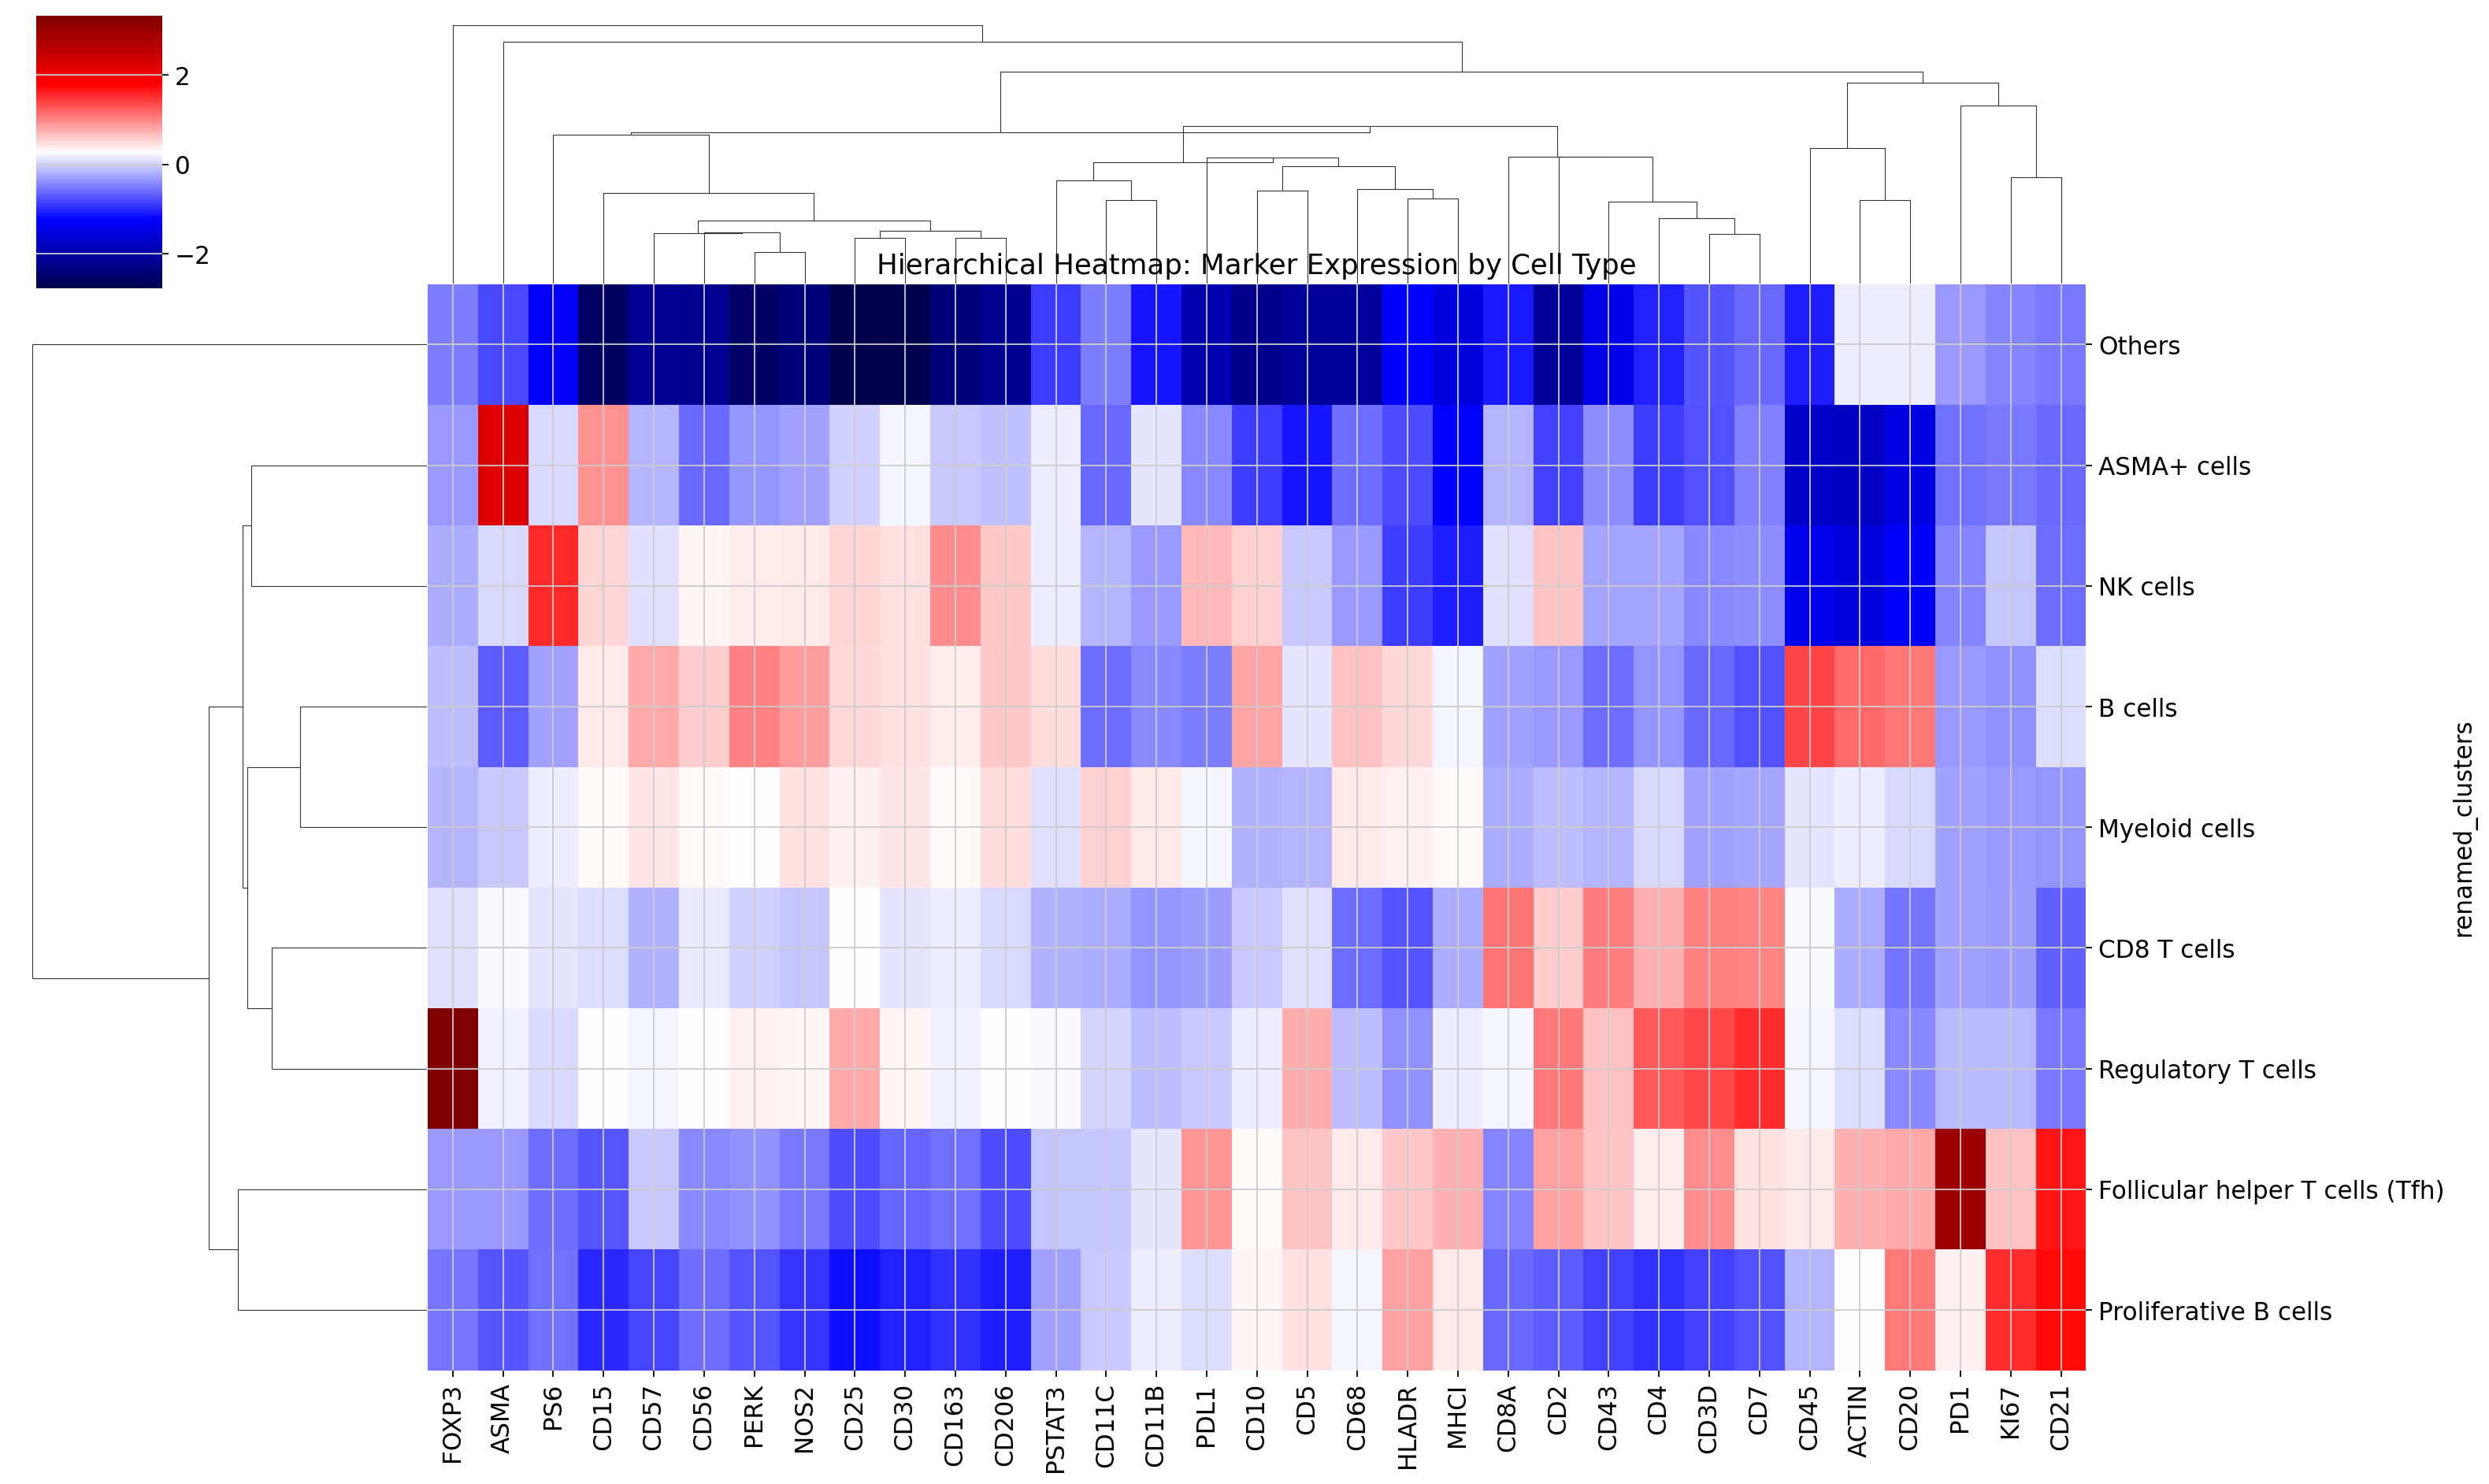

In [13]:
# Create hierarchical heatmap
_, clustergrid, _ = hierarchical_heatmap(
    adata,
    annotation=renamed_column,
    features=None,
    layer=norm_zscore_output_layer,
    cluster_feature=True,
    cluster_annotations=True,
    standard_scale=None,
    z_score=None,
    swap_axes=False,
    rotate_label=False,
    figsize=(20, 12),
    dendrogram_ratio=(0.2, 0.2),
    cmap='seismic'
)

clustergrid.ax_heatmap.set_title('Hierarchical Heatmap: Marker Expression by Cell Type', 
                                fontsize=16)
plt.show()

### 6.2 Sankey Diagram

Visualize the relationship between original clusters and annotated cell types. 

SPAC's Sankey Plot function visualizes annotation relationships within datasets, offering both static and interactive plots. It represents the flow and connection between labels that exist in two sets of annotations, helping users understand how different labels relate to one another. This tool is useful for visualizing complex relationships in biological data, such as the progression of cell states or the connection between different cell types.

Similarly, SPAC's Relational Heatmap function visualizes the relationships between the labels that exist in two annotations. It provides a detailed heatmap that shows how categories from source and target annotations are related, helping users understand complex interactions, such as cellular phenotypes distribution over treatments, region of interests, and clustering results.





Available annotations in adata.obs:
['broad_cell_type', 'detailed_cell_type', 'manual_phenotype', 'phenograph_k60_r1', 'renamed_clusters', 'CD3Dspatial_plot', 'CD20spatial_plot']


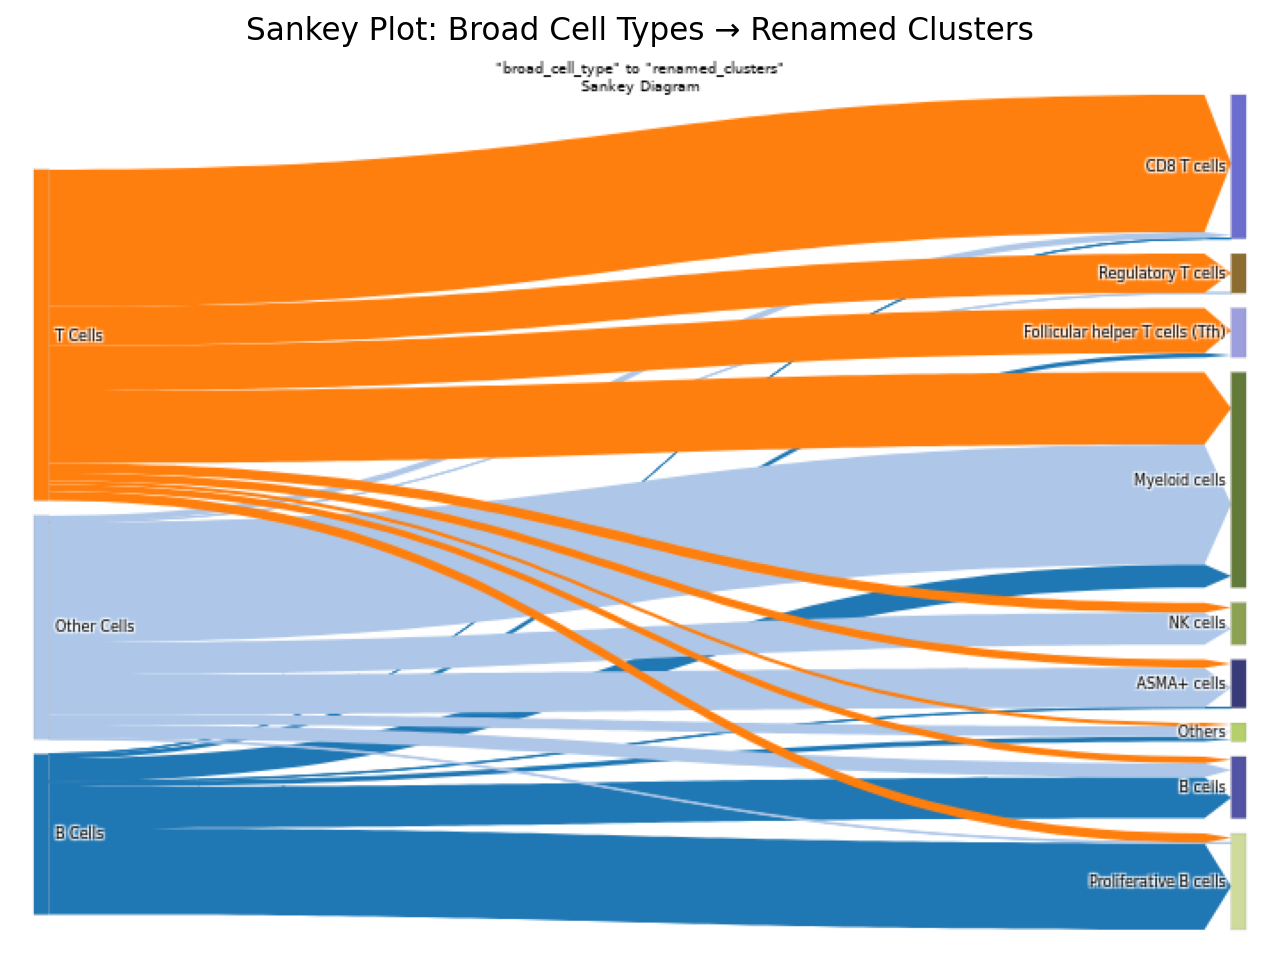

In [14]:
print("Available annotations in adata.obs:")
print(adata.obs.columns.tolist())

# Generate Sankey plot
fig = sankey_plot(
    adata=adata,
    source_annotation='broad_cell_type',
    target_annotation='renamed_clusters',
    source_color_map='tab20',
    target_color_map='tab20b',
    sankey_font=8,
    prefix=False
)

# If you call display(fig) here, the interactive figure may open in a new window.
# !pip install --upgrade nbformat
# display(fig)

# OR Use matplotlib display: convert to static image and display with matplotlib
# Convert to image bytes
img_bytes = fig.to_image(format="png")

# Display with matplotlib
img = PILImage.open(BytesIO(img_bytes))
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Sankey Plot: Broad Cell Types → Renamed Clusters')
plt.show()

## Step 7: Spatial Plot Analysis

SPAC provides two methods: 1. static spatial visualizations of single-cell data, providing a snapshot of cellular features or annotations across a sample; 2. interactive, real-time visual explorations of single-cell spatial data for in-depth analysis.

Specifically, Spatial Plot uses spatial coordinates to plot the chosen feature or annotation across the spatial layout of a single slide. The selection of feature or annotation to color the cells, which could be related to cellular characteristics or experimental conditions, is mutual excusively. Specific examples are shown below.

Interactive Spatial Plot creates dynamic, interactive visualizations by leveraging Plotly Express to generate scatter plots that vividly represent cellular distributions and annotations in a tissue sample. 

### 7.1 Spatial Distribution of Cell Types

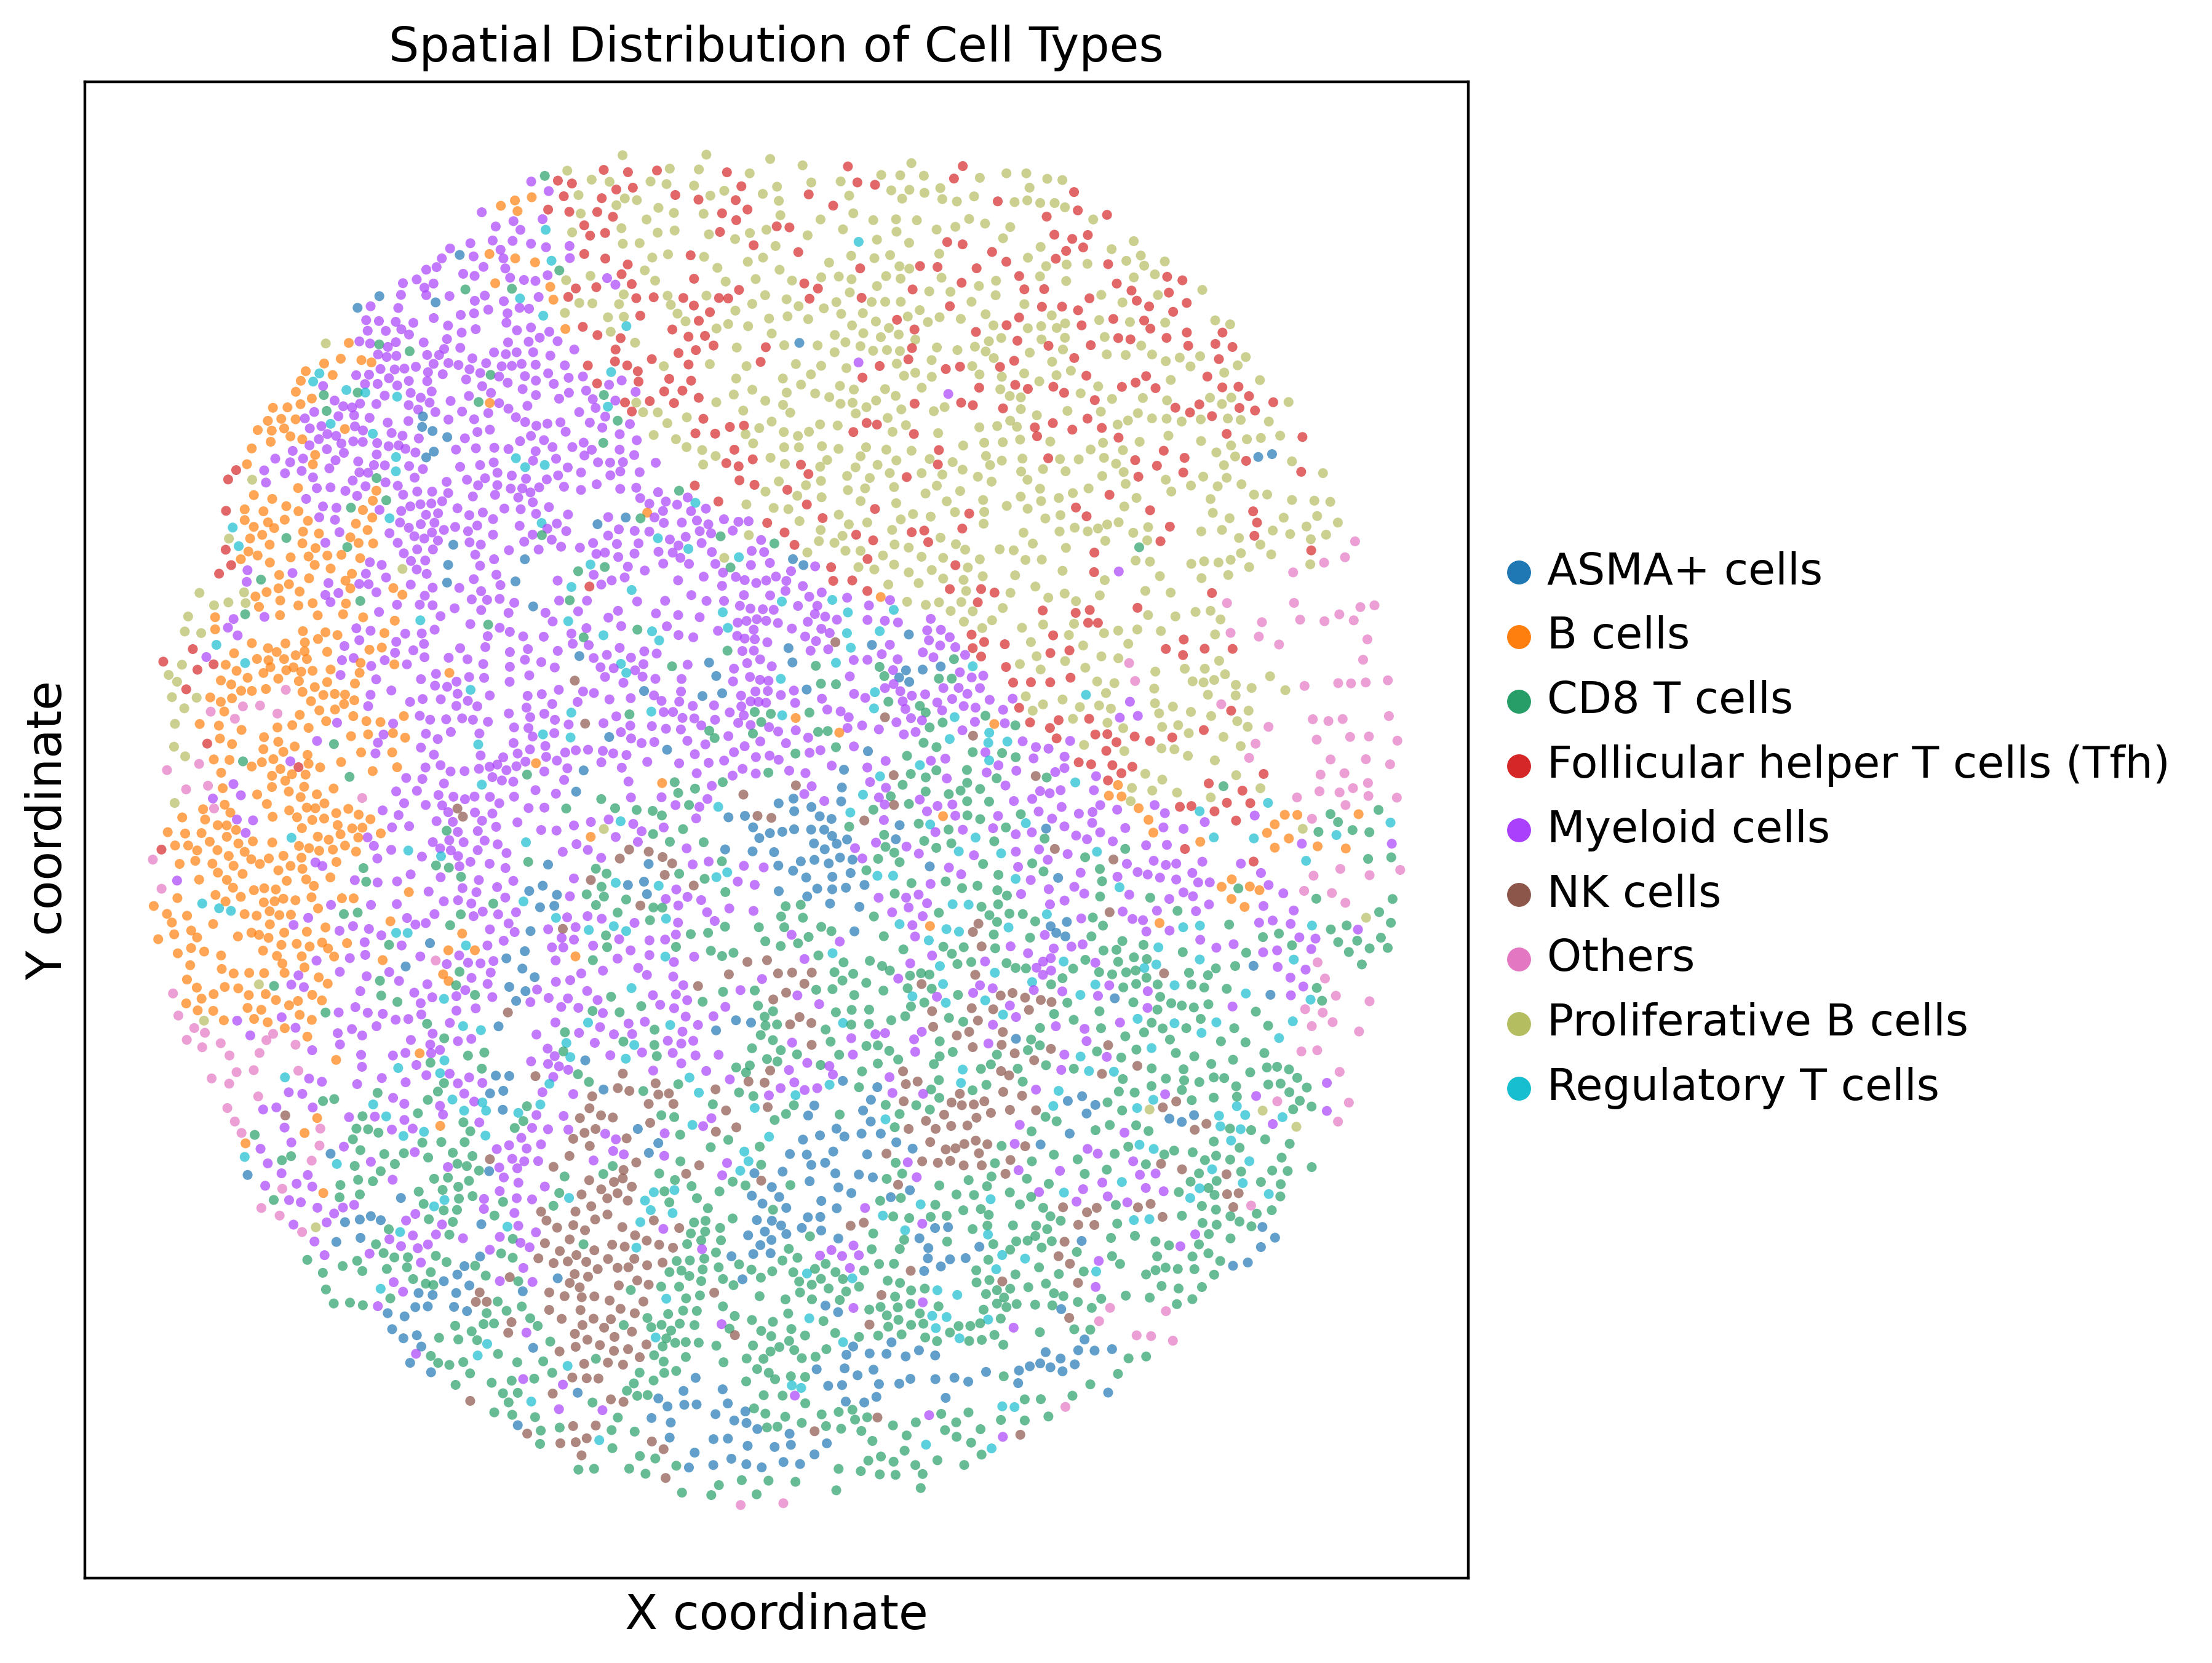

In [15]:
# Create spatial plot
annotation = "renamed_clusters"
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

spatial_plot(
    adata=adata,
    annotation=annotation,
    spot_size=8,
    alpha=0.7,
    ax=ax
)

ax.set_title(f'Spatial Distribution of Cell Types', fontsize=14)
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
plt.show()

### 7.2 Spatial Expression of Key Markers

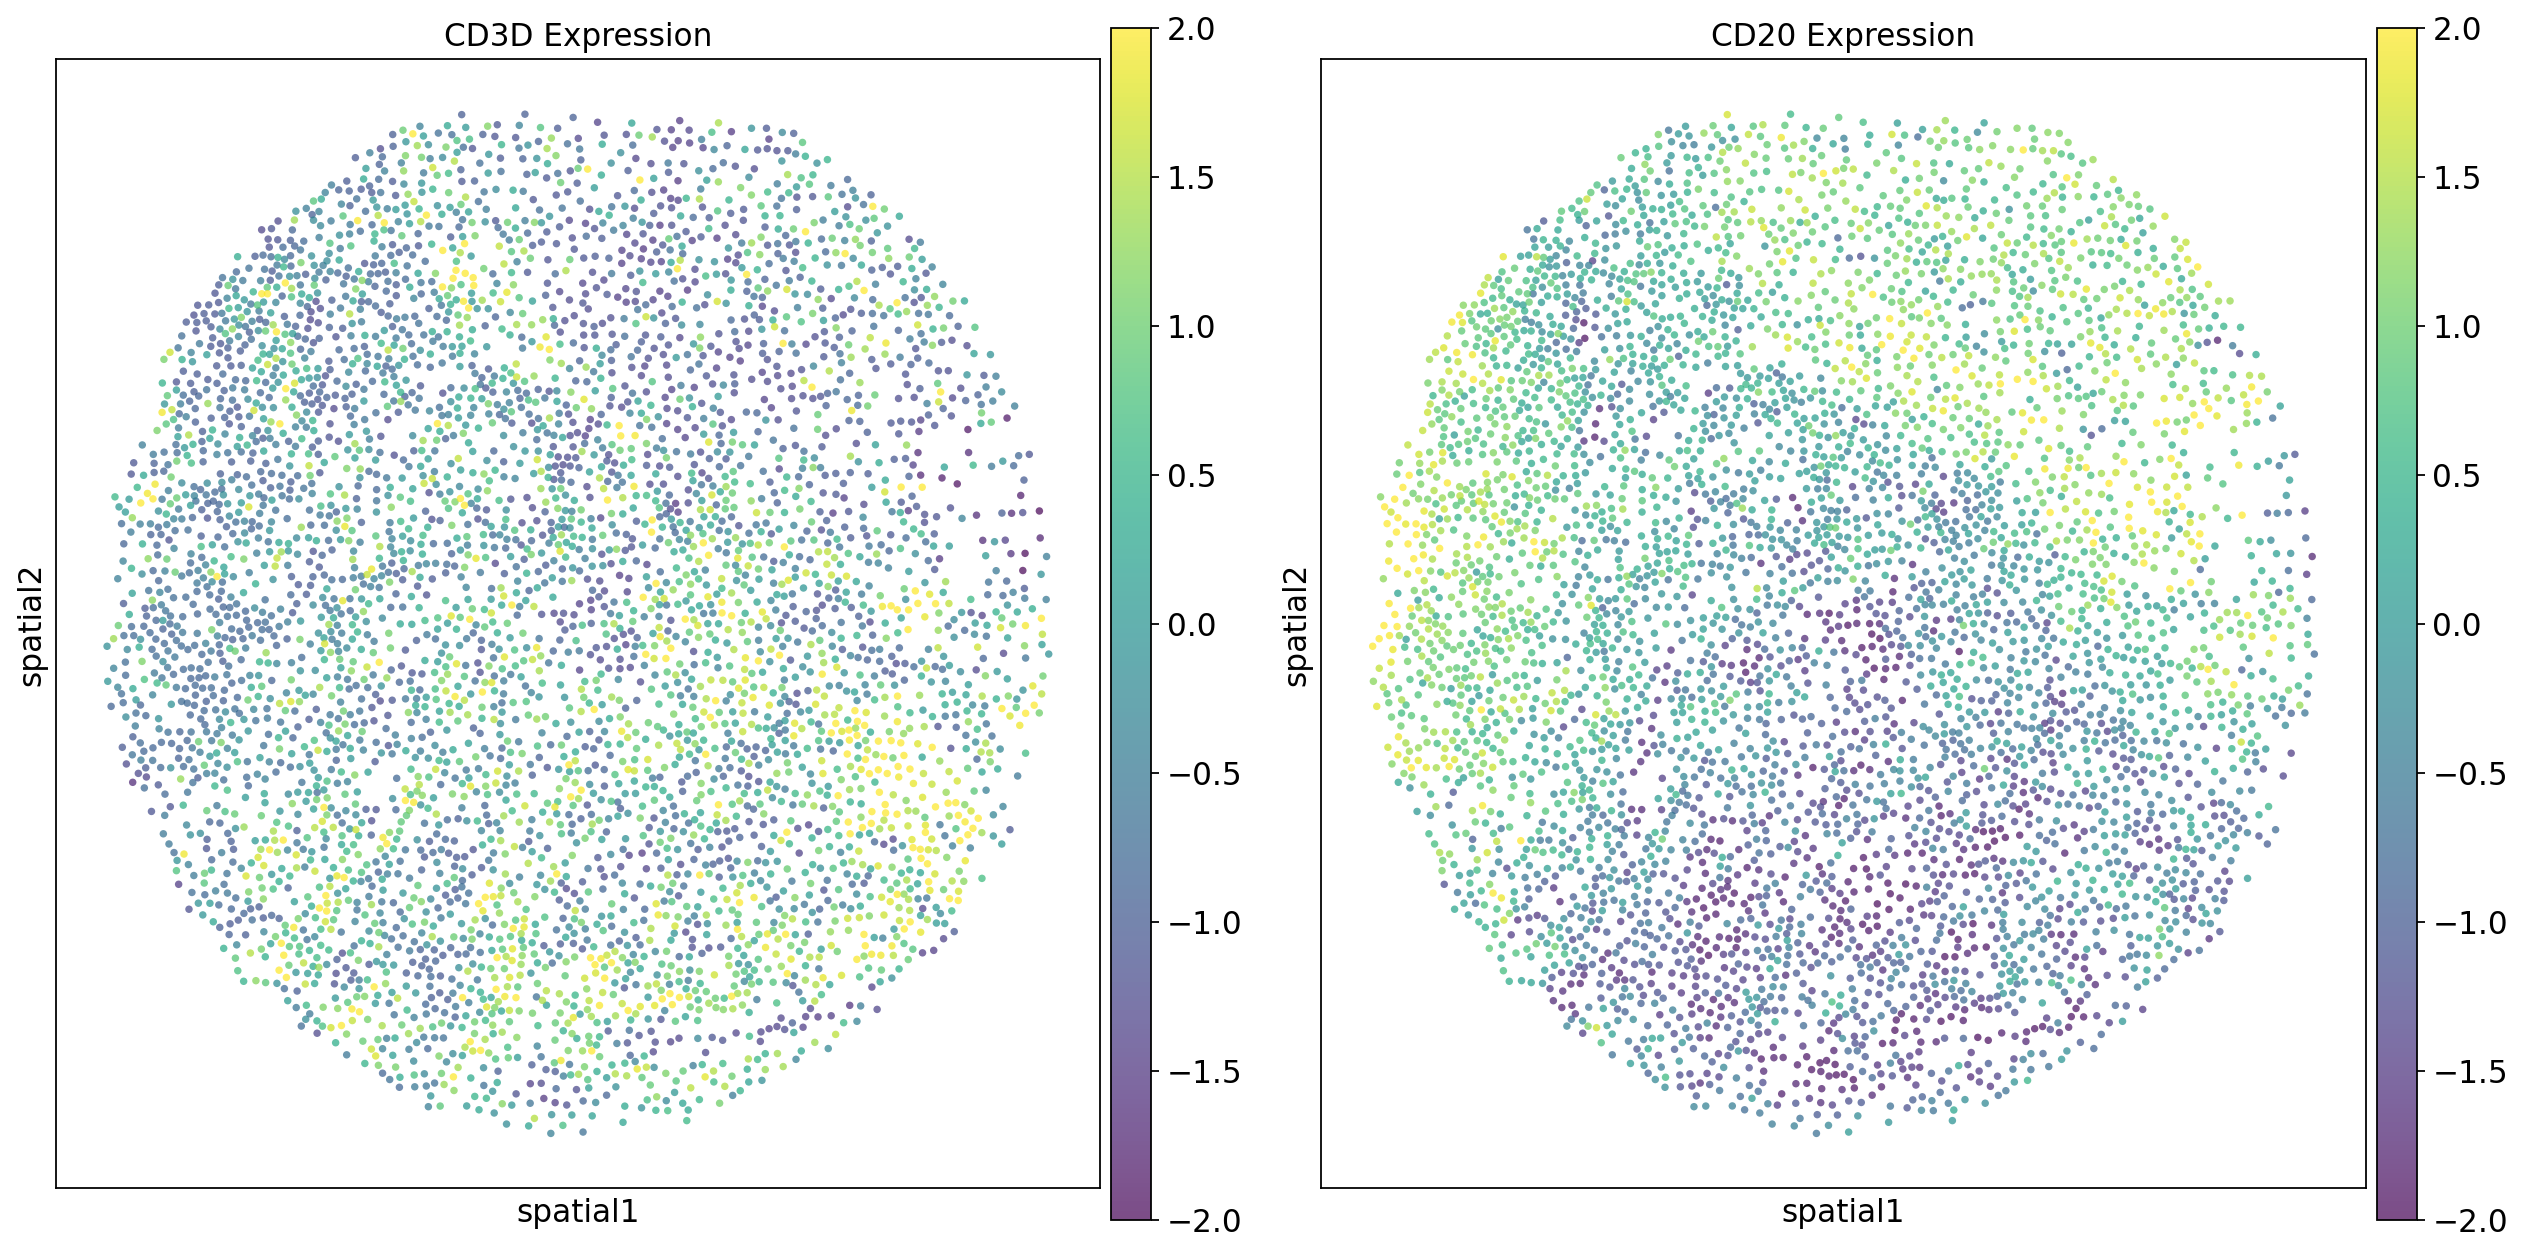

In [16]:
# Plot CD3D and CD20 spatial distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# CD3D distribution
spatial_plot(
    adata=adata,
    feature='CD3D',
    layer=norm_zscore_output_layer,
    spot_size=8,
    alpha=0.7,
    ax=axes[0],
    vmin=-2,
    vmax=2
)
axes[0].set_title('CD3D Expression')

# CD20 distribution
spatial_plot(
    adata=adata,
    feature='CD20',
    layer=norm_zscore_output_layer,
    spot_size=8,
    alpha=0.7,
    ax=axes[1],
    vmin=-2,
    vmax=2
)
axes[1].set_title('CD20 Expression')

plt.tight_layout()
plt.show()

## Step 8: Neighborhood Analysis

### 8.1 Calculate Nearest Neighbors

See lymphnode_analysis.ipynb for more details

### 8.2 Visualize Nearest Neighbor Distances

Analyze the spatial proximity between Tfh cells and other cell types.

The Nearest Neighbor Visualization function utilizes precomputed nearest neighbor distances between every source phenotype and the closest neighbor phenotype from an upstream calculation step. It displays these nearest neighbor distances (for all cells of source phenotype) in a variety of plot formats (e.g., box, violin, histogram, or KDE). 



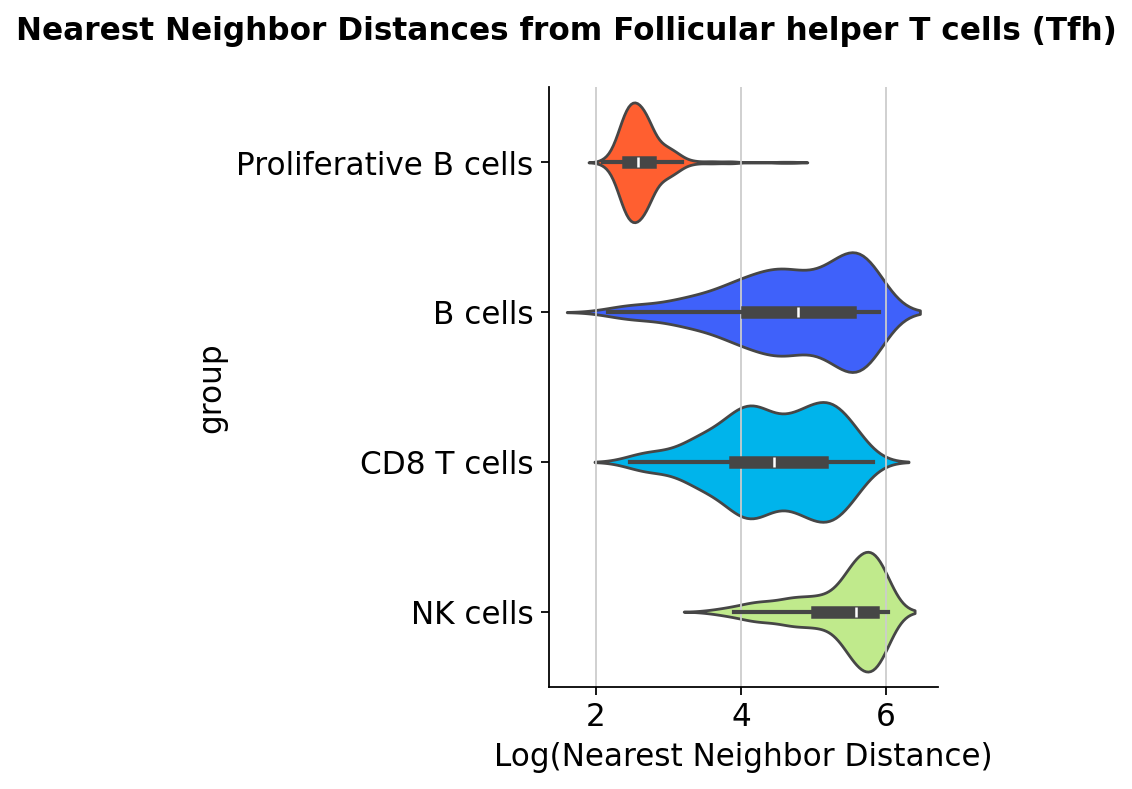

Key finding: Tfh cells are closest to Proliferative B cells,
supporting their role in germinal center function.


In [17]:
# Visualize nearest neighbor distances from Tfh cells
source_label = "Follicular helper T cells (Tfh)"
target_labels = ["Proliferative B cells", "B cells", "CD8 T cells", "NK cells"]

result_dict = visualize_nearest_neighbor(
    adata=adata,
    annotation="renamed_clusters",
    spatial_distance="spatial_distance",
    distance_from=source_label,
    distance_to=target_labels,
    method="numeric",
    plot_type="violin",
    log=True,
    hue="group",
    palette="Set2"
)

plt.suptitle(f'Nearest Neighbor Distances from {source_label}', 
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("Key finding: Tfh cells are closest to Proliferative B cells,")
print("supporting their role in germinal center function.")

### 8.3 Neighborhood Enrichment Analysis

See lymphnode_analysis.ipynb for more details

## Step 9: Ripley's L Analysis

### 9.1 Calculate Ripley's L Statistic

Calculates the Ripley L statistic that measures the amount of clustering/dispersion between two cell phenotypes at different radii.

Specifically, Ripley's L statistic is a method to analyze spatial patterns of cells, determining if two cell types are clustered, randomly distributed, or evenly spaced at different distances. It calculates the L value for various radii by counting the number of neighboring cells of one type (the neighbor phenotype) within a maximum radius R of another type (the center phenotype) and normalizing this count by the overall density of cells in the region. This analysis employs edge correction by excluding cells located near the region's borders within the analytical radius to mitigate edge-effect biases. The method assumes the area analyzed is uniform and that there are enough cells (e.g., at least 30) of both phenotypes to ensure reliable results. 

Ripley’s L can be calculated for regions from different treatment types or compared against a baseline hypothesis of complete spatial randomness (CSR), where cells are randomly distributed within the region based on a Poisson point process. For a valid CSR comparison, the region must be homogeneous and free from barriers like blood vessels that restrict cell movement.

The CSR baseline is created by simulating multiple random distributions of cells. These simulations generate a 95% confidence interval, representing the range of values expected under random conditions. By comparing the observed L statistic to this confidence interval, the analysis identifies distances where the observed cell distribution significantly deviates from randomness, revealing aggregation or dispersion patterns.

This function calculates the Ripley L for two phenotypes at different Radii. Please refer Plot Ripley L function visulizing these results.


EDGE CORRECTION BENCHMARKING FOR RIPLEY'S L ANALYSIS
Demonstrating the impact of edge correction on spatial statistics
--------------------------------------------------------------------------------

Preparing separate AnnData objects for independent analysis...
✓ Created independent copies

A.1 Ripley's L WITH Edge Correction (Guard-Zone Method)
--------------------------------------------------


<Figure size 800x480 with 0 Axes>

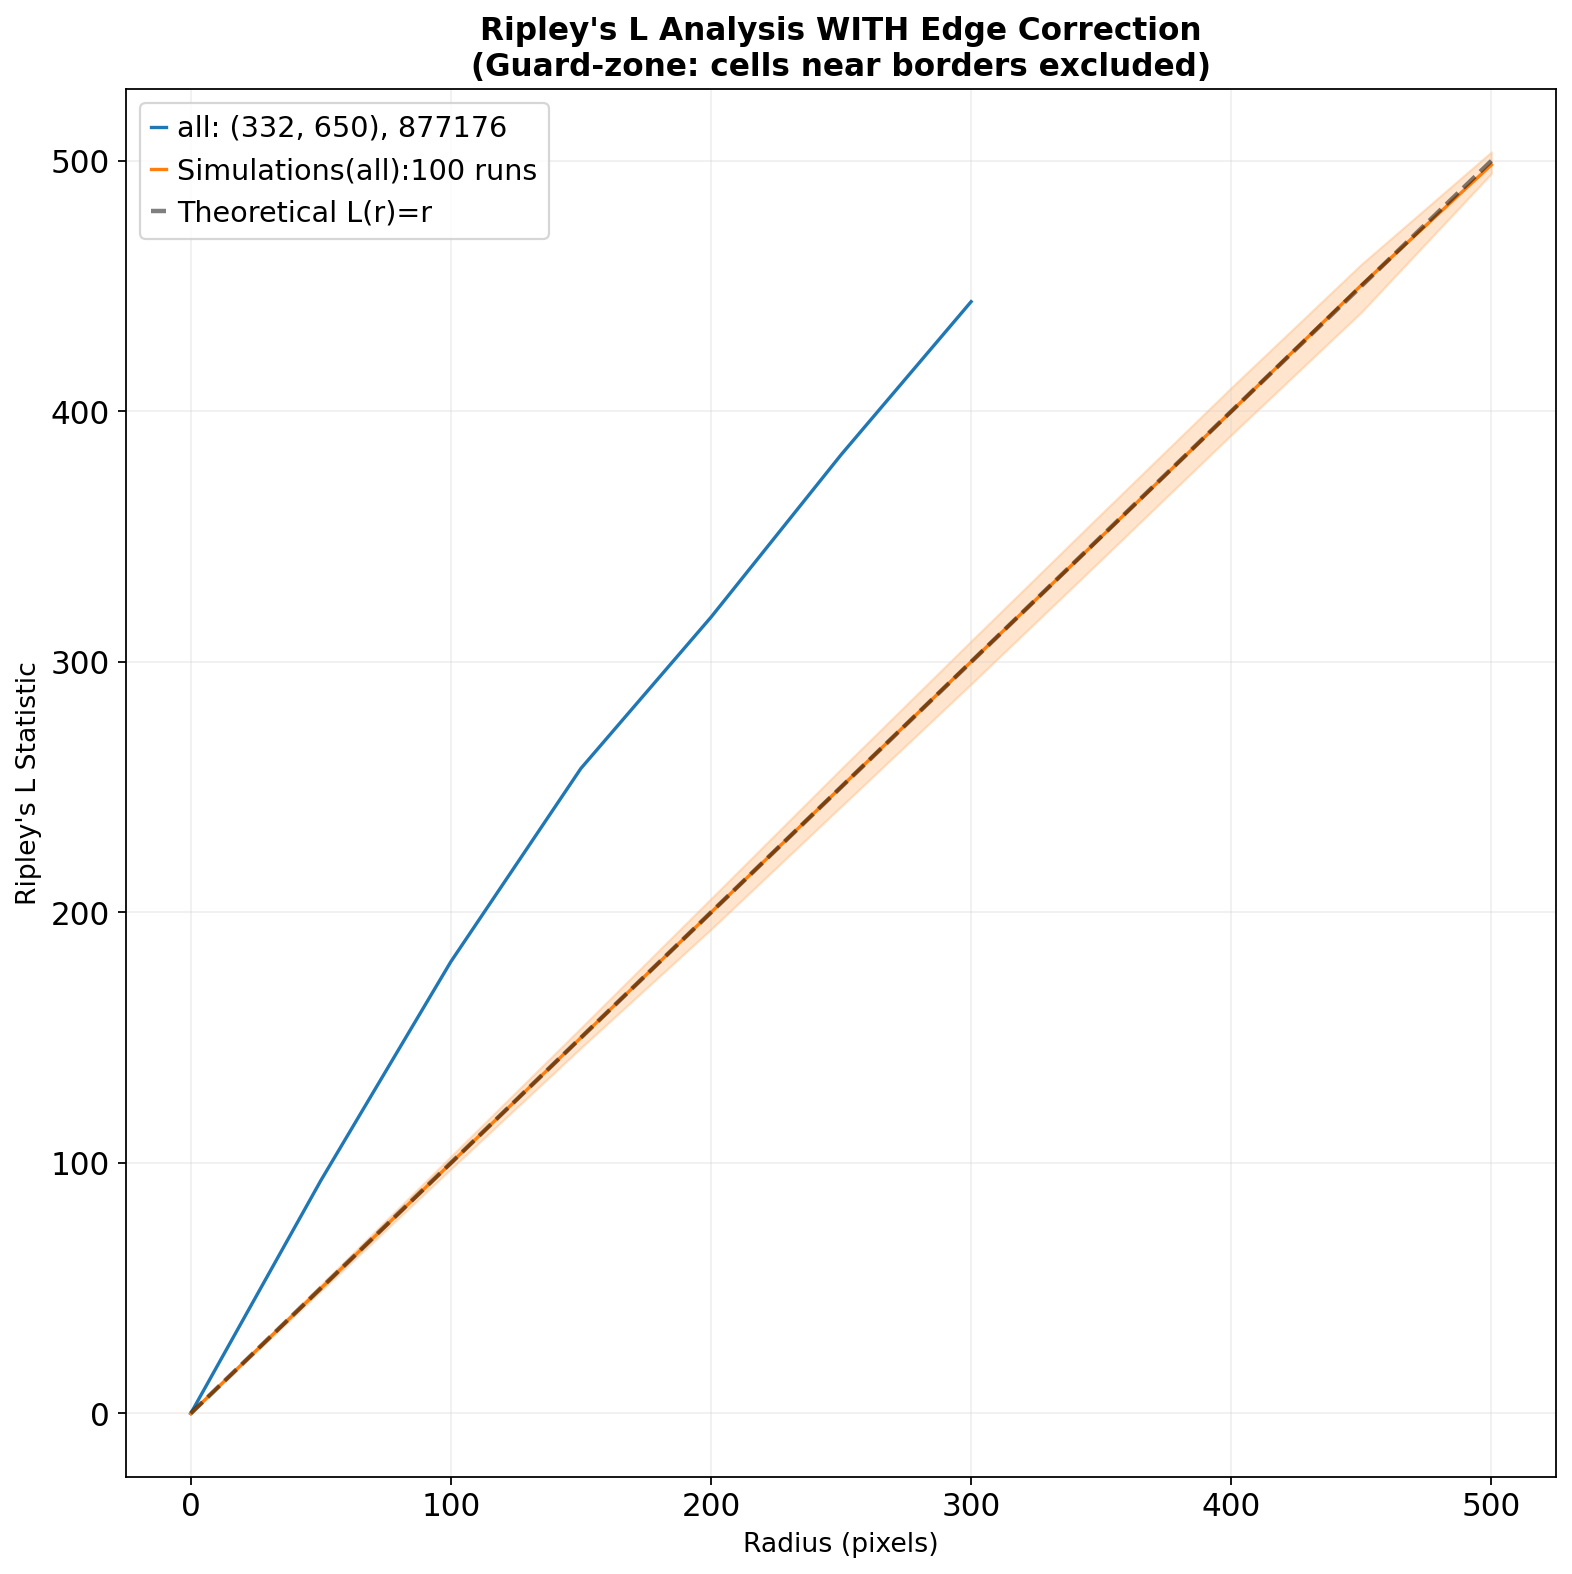

✓ WITH edge correction complete
  Note: CSR envelope aligns with L(r)=r line (45° diagonal)
  Note: Empirical curve may stop earlier when no eligible centers remain

A.2 Ripley's L WITHOUT Edge Correction
--------------------------------------------------


<Figure size 800x480 with 0 Axes>

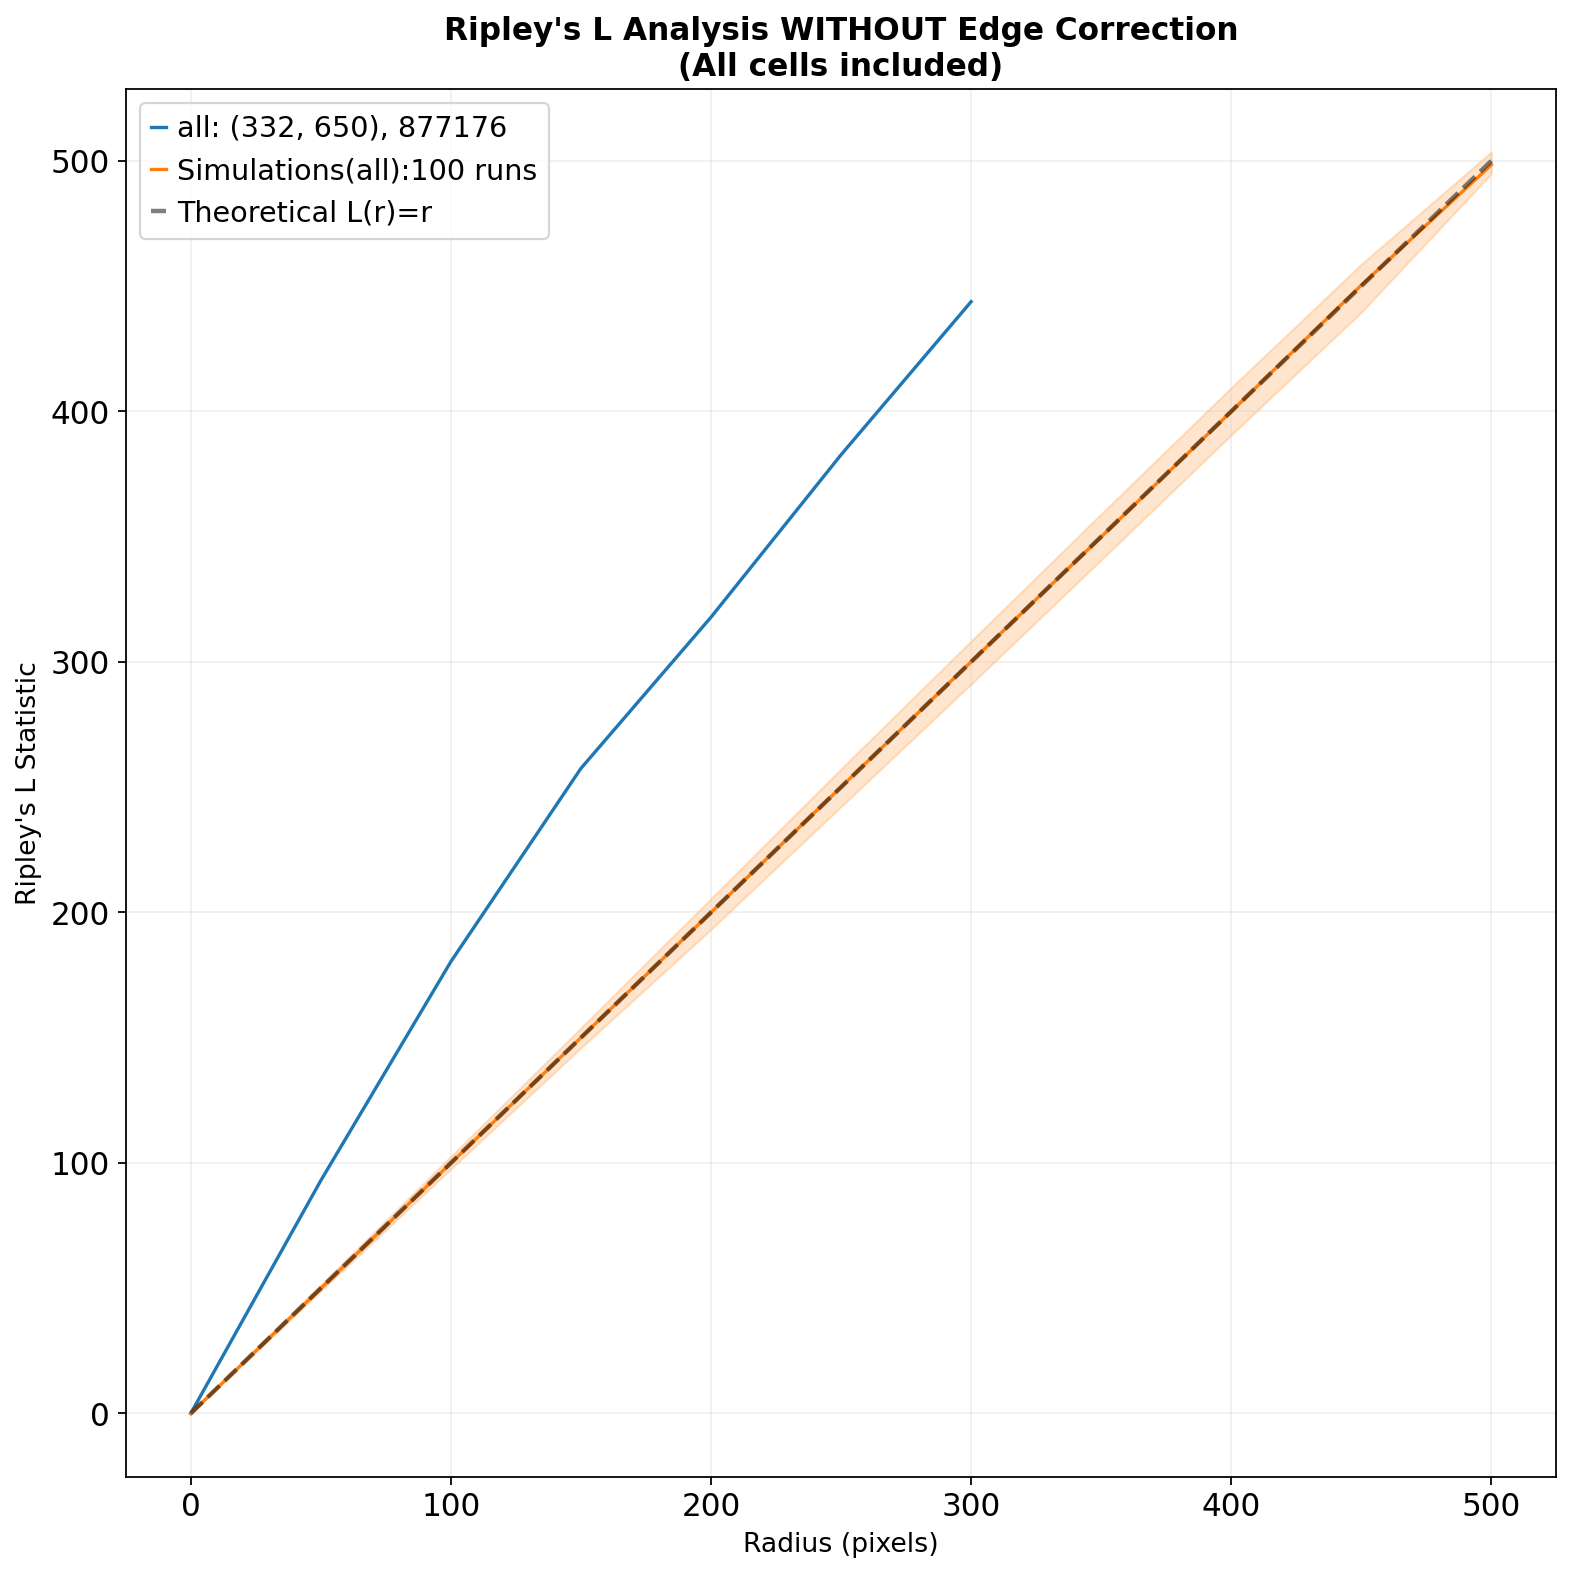

✓ WITHOUT edge correction complete
  Note: CSR envelope bends below L(r)=r at large radii (boundary undercount)

KEY OBSERVATIONS FROM EDGE CORRECTION BENCHMARK

See lymphnode_analysis.ipynb for more details


✓ Benchmarking complete. Edge-corrected results set as default.
✓ Both analyses stored in adata.uns for reference:
  - adata.uns['ripley_l_with_edge']
  - adata.uns['ripley_l_without_edge']


In [18]:
"""
Edge Correction Benchmarking for Ripley's L Analysis
================================================================================
This section addresses the reviewer's comment about benchmarking SPAC's edge 
correction implementation compared to methods without edge correction.
================================================================================
"""

import copy
import matplotlib.pyplot as plt

print("=" * 80)
print("EDGE CORRECTION BENCHMARKING FOR RIPLEY'S L ANALYSIS")
print("=" * 80)
print("Demonstrating the impact of edge correction on spatial statistics")
print("-" * 80 + "\n")

# Define extended radii for comprehensive analysis
radii = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

# ============================================================================
# Clone AnnData objects for separate analysis
# ============================================================================
print("Preparing separate AnnData objects for independent analysis...")
adata_with_edge = copy.deepcopy(adata)
adata_without_edge = copy.deepcopy(adata)
print("✓ Created independent copies\n")

# ============================================================================
# A.1 Calculate and Plot Ripley's L WITH Edge Correction
# ============================================================================
print("A.1 Ripley's L WITH Edge Correction (Guard-Zone Method)")
print("-" * 50)

# # Calculate WITH edge correction on first copy
# ripley_l(
#     adata_with_edge,
#     annotation="renamed_clusters",
#     phenotypes=["Follicular helper T cells (Tfh)", "Proliferative B cells"],
#     distances=radii,
#     n_simulations=100,
#     seed=42,
#     spatial_key="spatial",
#     edge_correction=True
# )

# Create fresh figure for WITH edge correction
plt.figure(figsize=(10, 6))
fig_with, df_with = plot_ripley_l(
    adata_with_edge,
    phenotypes=("Follicular helper T cells (Tfh)", "Proliferative B cells"),
    sims=True,
    return_df=True
)

# Add theoretical L(r)=r line
plt.plot([0, max(radii)], [0, max(radii)], 'k--', alpha=0.5, linewidth=2, label='Theoretical L(r)=r')
plt.title("Ripley's L Analysis WITH Edge Correction\n(Guard-zone: cells near borders excluded)", 
          fontsize=14, fontweight='bold')
plt.xlabel("Radius (pixels)", fontsize=12)
plt.ylabel("Ripley's L Statistic", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ WITH edge correction complete")
print("  Note: CSR envelope aligns with L(r)=r line (45° diagonal)")
print("  Note: Empirical curve may stop earlier when no eligible centers remain\n")

# ============================================================================
# A.2 Calculate and Plot Ripley's L WITHOUT Edge Correction
# ============================================================================
print("A.2 Ripley's L WITHOUT Edge Correction")
print("-" * 50)

# Calculate WITHOUT edge correction on second copy
# ripley_l(
#     adata_without_edge,
#     annotation="renamed_clusters",
#     phenotypes=["Follicular helper T cells (Tfh)", "Proliferative B cells"],
#     distances=radii,
#     n_simulations=100,
#     seed=42,
#     spatial_key="spatial",
#     edge_correction=False
# )

# Create fresh figure for WITHOUT edge correction
plt.figure(figsize=(10, 6))
fig_without, df_without = plot_ripley_l(
    adata_without_edge,
    phenotypes=("Follicular helper T cells (Tfh)", "Proliferative B cells"),
    sims=True,
    return_df=True
)

# Add theoretical L(r)=r line
plt.plot([0, max(radii)], [0, max(radii)], 'k--', alpha=0.5, linewidth=2, label='Theoretical L(r)=r')
plt.title("Ripley's L Analysis WITHOUT Edge Correction\n(All cells included)", 
          fontsize=14, fontweight='bold')
plt.xlabel("Radius (pixels)", fontsize=12)
plt.ylabel("Ripley's L Statistic", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ WITHOUT edge correction complete")
print("  Note: CSR envelope bends below L(r)=r at large radii (boundary undercount)\n")

# ============================================================================
# A.3 Key Observations and Interpretation
# ============================================================================
print("=" * 80)
print("KEY OBSERVATIONS FROM EDGE CORRECTION BENCHMARK")
print("=" * 80)

print("""
See lymphnode_analysis.ipynb for more details
""")

# Store results back to original adata with edge correction as default
# adata.uns['ripley_l_with_edge'] = adata_with_edge.uns['ripley_l'].copy()
# adata.uns['ripley_l_without_edge'] = adata_without_edge.uns['ripley_l'].copy()
# adata.uns['ripley_l'] = adata_with_edge.uns['ripley_l'].copy()

print("\n✓ Benchmarking complete. Edge-corrected results set as default.")
print("✓ Both analyses stored in adata.uns for reference:")
print("  - adata.uns['ripley_l_with_edge']")
print("  - adata.uns['ripley_l_without_edge']")
print("=" * 80)

## Step 10: Summary and Conclusions

See lymphnode_analysis.ipynb for more details

### Data Preservation
All analysis results are stored in the `adata` object in memory and can be accessed for further analysis or exported as needed.


In [19]:
# Display final AnnData object information
print("Final AnnData object:")
print(adata)
print(f"\nAvailable layers: {list(adata.layers.keys())}")
print(f"Available annotations: {list(adata.obs.columns)}")
print(f"Spatial coordinates: {adata.obsm.keys()}")


Final AnnData object:
AnnData object with n_obs × n_vars = 4825 × 33
    obs: 'broad_cell_type', 'detailed_cell_type', 'manual_phenotype', 'phenograph_k60_r1', 'renamed_clusters', 'CD3Dspatial_plot', 'CD20spatial_plot'
    uns: 'phenograph_features', 'phenograph_k60_r1_colors', 'renamed_clusters_colors', '_spac_palettes', 'spatial_neighbors', 'renamed_clusters_plot_nhood_enrichment', 'ripley_l_with_edge', 'ripley_l_without_edge', 'ripley_l'
    obsm: 'spatial', 'X_umap', 'spatial_distance'
    layers: 'arcsinh_percentile', 'arcsinh_z_scores'
    obsp: 'spatial_connectivities', 'spatial_distances'

Available layers: ['arcsinh_percentile', 'arcsinh_z_scores']
Available annotations: ['broad_cell_type', 'detailed_cell_type', 'manual_phenotype', 'phenograph_k60_r1', 'renamed_clusters', 'CD3Dspatial_plot', 'CD20spatial_plot']
Spatial coordinates: KeysView(AxisArrays with keys: spatial, X_umap, spatial_distance)
